# 0602 — cGAN Training: Synthesizing the Pienza Manifold

Trains a conditional GAN (Generator + Discriminator) on 5 core physical trip variables, conditioned on categorical context (hour, day, product tier, zones, rejection reason), to synthesize a ~1M-row market manifold. Includes the full data-prep history (two supersede iterations kept for traceability) and an extensive statistical audit battery comparing the synthetic manifold against ground truth.

```mermaid
flowchart TD
    P1["Phase 1\nSetup & ingestion:\nBigQuery connection, FORCE_UPDATE toggle,\nv_ML_Supervised pull"] --> B["Phase 2\nData preprocessing\n(v2.17 physics + v3.2 pickup filter\n-> v5.0 final)"]
    B --> C["Phase 3\nGenerator + Discriminator\narchitecture"]
    C --> D["Phase 4\nAdversarial training\n(cache-aware)"]
    D --> E["Phase 5\nManifold synthesis\n(~1M rows)"]
    E --> F["Phase 6\nStatistical audit battery\n(KS, JS, TVD, correlation)"]

    classDef default stroke:#21918c,stroke-width:2px;
    linkStyle default stroke:#21918c,stroke-width:2px;
```


## Phase 1 — Setup & ingestion

Connects to BigQuery, sets the visual canon and the `FORCE_UPDATE` toggle (controls whether training/synthesis re-runs or loads cached artifacts), and pulls the master offer view.

#### 1.1 — BigQuery connection, visual canon, and cache toggle

In [147]:
import os
import warnings

import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.cloud import bigquery
from google.oauth2 import service_account
from scipy import stats
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import tensorflow as tf
from tensorflow.keras import Input, Model, layers
import time
import joblib
from IPython.display import clear_output
from scipy.spatial.distance import jensenshannon
from scipy.stats import ks_2samp

try:
    import h3
except ImportError:
    !pip install h3 -q
    import h3

warnings.filterwarnings('ignore')

# --- Paths ---
BASE_DIR = "/workspaces/pienza"
ASSETS_DIR = os.path.join(BASE_DIR, "assets")
DUMP_DIR = os.path.join(BASE_DIR, "data", "dumped_files")
SA_PATH = "/workspaces/pienza/secrets/service-account.json"
GEOJSON_PATH = os.path.join(ASSETS_DIR, "poly.geojson")
os.makedirs(DUMP_DIR, exist_ok=True)

# --- Cache control: set True to force retraining/resynthesis even if cached artifacts exist ---
FORCE_UPDATE = False

# --- BigQuery connection ---
PROJECT_ID = '645009831643'
DATASET_CORE = 'pienza_mini'

if os.path.exists(SA_PATH):
    print(f"Service account: {os.path.basename(SA_PATH)}")
    credentials = service_account.Credentials.from_service_account_file(SA_PATH)
    client = bigquery.Client(credentials=credentials, project=PROJECT_ID)

    try:
        client.query("SELECT 1").result()
        print(f"Data connection stable (project: {PROJECT_ID})")
    except Exception as e:
        print(f"PERMISSIONS ERROR: check the service account JSON.\n{e}")
else:
    print(f"CRITICAL: file not found at {SA_PATH}")

# --- Visual canon ---
PIENZA_PURPLE, PIENZA_TEAL = '#440154', '#21918c'
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.facecolor': '#FAFAFA', 'axes.facecolor': '#FAFAFA'})

print("\nSetup ready.")


Service account: service-account.json
Data connection stable (project: 645009831643)

Setup ready.


#### 1.2 — Data ingestion

Extracts the high-fidelity `v_ML_Supervised` view from BigQuery — the raw material for the manifold forge.

In [148]:
def ingest_pienza_gold():
    print(f"Ingesting master view from {PROJECT_ID}.{DATASET_CORE}...")

    query = f"""
        SELECT *
        FROM `{PROJECT_ID}.{DATASET_CORE}.v_ML_Supervised`
        WHERE upfront_fare IS NOT NULL
    """

    try:
        df = client.query(query).to_dataframe()
        print(f"Ingestion successful: {len(df):,} records loaded into memory.")
        return df
    except Exception as e:
        print(f"INGESTION FAILED: {e}")
        print("   Verify that 1.1 was executed and DATASET_CORE is defined.")
        return None

df_raw = ingest_pienza_gold()
if df_raw is not None:
    display(df_raw.head())


Ingesting master view from 645009831643.pienza_mini...
Ingestion successful: 4,765 records loaded into memory.


,offer_id,session_fk,ocr_fk,image_content_hash,offer_timestamp,hour_of_day,upfront_fare,time_to_pickup_sec,dist_to_pickup_km,est_trip_time_sec,...,dropoff_polygon_id,dropoff_polygon_name,dropoff_h3_hex_id,dropoff_hdbscan_id,dropoff_hdbscan_name,realized_traffic_index,historical_rolling_avg_traffic_index,traffic_volatility_index_ml,traffic_volatility_index_eda,heuristic_flag_context
0,OF00001,SID0001,OCR00001,6f53fbeb55d097dbd8c1087a537cbe4589a05eaea7398d...,2025-08-22 06:44:33,6,204.24,840.0,4.9,2580.0,...,-1,unassigned,89499516bafffff,-1,unassigned,NaN,NaN,NaN,NaN,NaN
1,OF00002,SID0001,OCR00002,fe824e63f500f8c99f017cc6d975d087f9d529e7a26997...,2025-08-22 06:45:06,6,173.86,300.0,1.5,2400.0,...,-1,unassigned,894995b1dd7ffff,-1,unassigned,NaN,NaN,NaN,NaN,NaN
2,OF00003,SID0001,OCR00003,64f34e64aaed7113e732d1434d857ac4de639b89626cf4...,2025-08-22 06:45:28,6,136.53,NaN,NaN,NaN,...,-1,unassigned,NaN,-2,missing_coordinates,NaN,NaN,NaN,NaN,NaN
3,OF00005,SID0001,OCR00005,3e028cf71edcd497a6dbd224b916da9a4ab024653e8409...,2025-08-22 07:25:22,7,95.27,420.0,1.7,1080.0,...,-1,unassigned,894995bab23ffff,-1,unassigned,NaN,NaN,NaN,NaN,NaN
4,OF00006,SID0001,OCR00006,ba2224442cb5087e9344dbe58dd87e877cb0d390935ae3...,2025-08-22 07:25:39,7,68.36,60.0,0.1,960.0,...,-1,unassigned,894995a31d7ffff,6,lomas_verdes,NaN,NaN,NaN,NaN,NaN


## Phase 2 — Data preprocessing

Cleans, consolidates, and scales the raw offers into the feature set the GAN trains on. This phase kept its full iteration history for traceability:

- **2.1** — first preprocessing pass (v2.17): uses an H3 hex grid for pickup location. Superseded, but kept to show the exploration path.
- **2.2** — audit of that H3 grid (kept for the same reason).
- **2.4 / 2.5** — two iterations of a point-in-polygon pickup filter (v3.1 anti-overlap, then v3.2 which fixes duplicate/NaN edge cases). v3.2 is the version actually used downstream.
- **2.8** — the final preprocessing pass (v5.0): combines v2.17's physics pipeline with the v3.2 point-in-polygon pickup filter instead of H3. This is what actually produces `df_gan_ready`, and everything after this phase depends on its output.

#### 2.1 — Data preprocessing v2.17 (pure physics & logs, H3 pickups)

First full data-prep pass: geospatial cleanup, product tier consolidation, dropoff zone topology, outlier trimming, Black-tier oversampling, and scaling. Uses an H3 hex grid (not point-in-polygon) for pickup location. Superseded by 2.8 (v5.0) — kept here for traceability of the exploration path, not used by later phases.

In [149]:
def execute_pienza_forge_v217(df_raw_source):
    print("Starting Pienza preprocessing v2.17")
    print("=" * 65)

    # --- 1. Initial state ---
    df = df_raw_source.copy()
    n_start = len(df)
    print(f"Raw input: {n_start:,} records detected.")

    # --- 2. Geospatial cleanup ---
    df = df.dropna(subset=['pickup_lat', 'pickup_lon', 'dropoff_lat', 'dropoff_lon'])
    n_gps = len(df)
    print(f"GPS cleanup: {n_start - n_gps} null rows dropped. (Remaining: {n_gps:,})")

    # --- 3. Product tier consolidation (1-2-3) ---
    df['product_category_fk'] = df['product_category_fk'].replace(3, 2).replace(4, 3)
    df = df[df['product_category_fk'].isin([1, 2, 3])].copy()
    n_cull = len(df)
    print(f"Category cull: {n_gps - n_cull} rows dropped.")
    print(f"   Mix: UberX: {len(df[df['product_category_fk']==1]):,}, Comfort: {len(df[df['product_category_fk']==2]):,}, Black: {len(df[df['product_category_fk']==3]):,}")

    # --- 4. Strategic topology (zone consolidation map) ---
    id_map = {-1:-1, 41:0, 42:0, 46:0, 43:1, 65:2, 62:2, 44:2, 36:2, 49:3, 52:3, 35:3, 50:4, 58:4, 25:5, 31:5, 63:6, 39:6, 51:7, 33:7, 37:8, 53:8, 48:8, 60:9, 57:10, 12:10, 32:10, 24:11, 40:12, 45:13, 59:13, 61:14, 38:14, 34:15, 30:16, 66:16, 17:17, 14:17, 22:17, 16:18, 13:18, 11:19, 15:20, 21:21, 20:21, 19:21, 18:22, 47:23, 55:23, 56:23, 54:24, 64:24, 71:25, 9:26, 70:27, 69:28, 8:29, 6:30, 7:30, 23:30, 3:31, 2:32, 4:33, 29:33, 68:34, 5:35, 27:36, 28:36, 1:37, 10:38, 0:39, 26:40, 67:41}
    df['id_agrupado'] = df['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)
    conditions = [(df['id_agrupado'] >= 0), (df['dropoff_hdbscan_id'] > -1)]
    choices = ["P_" + df['id_agrupado'].astype(str), "C_" + df['dropoff_hdbscan_id'].astype(str)]
    df['dropoff_zone_id'] = np.select(conditions, choices, default="Unassigned")
    print(f"Topology: {df['dropoff_zone_id'].nunique()} strategic zones forged.")

    # --- 5. Feature injection ---
    df['offer_timestamp'] = pd.to_datetime(df['offer_timestamp'])
    df['hour_of_day'] = df['offer_timestamp'].dt.hour
    df['pickup_h3_id'] = df.apply(lambda x: h3.latlng_to_cell(x['pickup_lat'], x['pickup_lon'], 9), axis=1)
    df['reason_primary_fk'] = df['reason_primary_fk'].fillna(99).astype(int)

    # --- 6. 3-sigma outlier sieve (Black tier protected) ---
    z_scores = np.abs(stats.zscore(df['eph_direct_index'].fillna(0)))
    mask_to_drop = (z_scores >= 3) & (df['product_category_fk'] != 3)
    df = df[~mask_to_drop].copy()
    print(f"Outlier sieve: {np.sum(mask_to_drop)} outliers removed.")

    # --- 7. Oversampling ---
    df_black = df[df['product_category_fk'] == 3]
    n_black_real = len(df_black)
    df = pd.concat([df] + [df_black] * 14, ignore_index=True)
    print(f"Oversampling: Black amplified ({n_black_real} -> {n_black_real*15}).")

    # --- 8. Atomic feature set definition (no incentives) ---
    SWITCH_COLS = ['hour_of_day', 'day_of_week', 'product_category_fk', 'dropoff_zone_id', 'pickup_h3_id', 'reason_primary_fk']

    PHYSICS_COLS = [
        'upfront_fare', 'est_trip_time_sec', 'est_trip_dist_km',
        'time_to_pickup_sec', 'dist_to_pickup_km'
    ]

    # --- 9. Hardening & logs ---
    df['upfront_fare'] = np.log1p(df['upfront_fare'].fillna(0))
    df['est_trip_dist_km'] = np.log1p(df['est_trip_dist_km'].fillna(0))
    df[PHYSICS_COLS] = df[PHYSICS_COLS].fillna(0.0)
    print("Hardening: incentives removed, pure physics normalized.")

    # --- 10. Encoding and scaling ---
    label_encoders = {}
    for col in SWITCH_COLS:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

    physics_scaler = MinMaxScaler(feature_range=(-1, 1))
    df[PHYSICS_COLS] = physics_scaler.fit_transform(df[PHYSICS_COLS])

    print("Scaling: atomic feature set in [-1, 1].")
    print("=" * 65)

    # --- Final check ---
    final_df = df[SWITCH_COLS + PHYSICS_COLS].copy()
    if final_df.isna().any().any():
        print("CRITICAL ALERT: NaNs detected.")
        display(final_df.isna().sum())
    else:
        print(f"Feature set finalized: {len(final_df):,} records | {len(PHYSICS_COLS)} physical vars.")

    return final_df, label_encoders, physics_scaler, SWITCH_COLS, PHYSICS_COLS

df_gan_ready, label_encoders, physics_scaler, SWITCH_COLS, PHYSICS_COLS = execute_pienza_forge_v217(df_raw)


Starting Pienza preprocessing v2.17
Raw input: 4,765 records detected.
GPS cleanup: 7 null rows dropped. (Remaining: 4,758)
Category cull: 114 rows dropped.
   Mix: UberX: 3,612, Comfort: 993, Black: 39
Topology: 67 strategic zones forged.


Outlier sieve: 67 outliers removed.
Oversampling: Black amplified (39 -> 585).
Hardening: incentives removed, pure physics normalized.
Scaling: atomic feature set in [-1, 1].
Feature set finalized: 5,123 records | 5 physical vars.


#### 2.2 — H3 resolution audit

Visualizes the H3 grid used by the v2.17 preprocessing pass, overlaid on the master polygons — for sanity-checking the (now-superseded) H3 pickup approach.

In [150]:
print("Starting H3 grid audit...")
print("-" * 65)

# Change this to experiment with a different H3 resolution than the
# training-time default (9, set in 2.1's execute_pienza_forge_v217).
H3_RESOLUTION = 9

if os.path.exists(GEOJSON_PATH):
    print(f"Loading master polygons from: {os.path.basename(GEOJSON_PATH)}")
    gdf_polygons = gpd.read_file(GEOJSON_PATH).to_crs("EPSG:4326")
else:
    print(f"CRITICAL ERROR: file not found at {GEOJSON_PATH}")
    raise FileNotFoundError("GeoJSON missing.")

def get_h3_index(lat, lon, res):
    try:
        return h3.latlng_to_cell(lat, lon, res)  # H3 v4+
    except AttributeError:
        return h3.geo_to_h3(lat, lon, res)  # H3 v3

# Recompute H3 cells directly from raw coordinates at H3_RESOLUTION, rather
# than decoding label_encoders (which is locked to whatever resolution 2.1 used).
print(f"Computing H3 cells at resolution {H3_RESOLUTION}...")
df_h3_audit = df_raw.dropna(subset=['pickup_lat', 'pickup_lon']).copy()
df_h3_audit['pickup_h3_id'] = df_h3_audit.apply(
    lambda row: get_h3_index(row['pickup_lat'], row['pickup_lon'], H3_RESOLUTION), axis=1
)
real_h3_strings = df_h3_audit['pickup_h3_id'].dropna().unique().tolist()
print(f"Density detected: {len(real_h3_strings)} unique blocks at resolution {H3_RESOLUTION}.")

# --- Initialize map ---
m_res = folium.Map(location=[19.4326, -99.1332], zoom_start=12, tiles="cartodbpositron")

# --- Render H3 mesh ---
print("Drawing high-resolution mesh...")
for h3_id in real_h3_strings:
    try:
        if h3_id in ['Unknown', '-1', 'None', 'unassigned']:
            continue
        try:
            geo_boundary = h3.cell_to_boundary(h3_id)  # H3 v4+
        except AttributeError:
            geo_boundary = h3.h3_to_geo_boundary(h3_id)  # H3 v3
        folium.Polygon(
            locations=geo_boundary,
            color=PIENZA_TEAL,
            weight=1,
            fill=True,
            fill_opacity=0.3,
            popup=f"H3 ID: {h3_id}"
        ).add_to(m_res)
    except Exception:
        continue

# --- Overlay master polygons (red) ---
folium.GeoJson(
    gdf_polygons,
    name="Master Polygons",
    style_function=lambda x: {'fillColor': 'red', 'color': 'red', 'weight': 2, 'fillOpacity': 0.1},
    tooltip=folium.GeoJsonTooltip(fields=['name'], aliases=['Zone:'])
).add_to(m_res)

print("\nRender complete.")
print(f"   Teal: H3 blocks at resolution {H3_RESOLUTION}.")
print("   Red: master polygons.")
m_res

Starting H3 grid audit...
-----------------------------------------------------------------
Loading master polygons from: poly.geojson
Computing H3 cells at resolution 9...
Density detected: 826 unique blocks at resolution 9.
Drawing high-resolution mesh...



Render complete.
   Teal: H3 blocks at resolution 9.
   Red: master polygons.


#### 2.3 — GeoJSON inspection

Quick structural check of the master polygon file.

In [151]:
GEO_PATH = GEOJSON_PATH
gdf_polygons = gpd.read_file(GEO_PATH)

print("GeoJSON structure:")
display(gdf_polygons.head(5))
print(f"\nColumns: {gdf_polygons.columns.tolist()}")


GeoJSON structure:


,name,styleUrl,styleHash,styleMapHash,stroke,stroke-opacity,stroke-width,fill,fill-opacity,geometry
0,polanco_parque_lincoln,#poly-000000-1200-77-nodesc,-30d7e096,{'normal': '#poly-000000-1200-77-nodesc-normal...,#000000,1,1.2,#000000,0.301961,"POLYGON Z ((-99.20321 19.42792 0, -99.20255 19..."
1,polanco_gandhi,#poly-000000-1200-77-nodesc,-30d7e096,{'normal': '#poly-000000-1200-77-nodesc-normal...,#000000,1,1.2,#000000,0.301961,"POLYGON Z ((-99.19135 19.43134 0, -99.1915 19...."
2,carso_antara_miyana,#poly-000000-1200-77-nodesc,-30d7e096,{'normal': '#poly-000000-1200-77-nodesc-normal...,#000000,1,1.2,#000000,0.301961,"POLYGON Z ((-99.20514 19.44679 0, -99.20522 19..."
3,sotelo,#poly-000000-1200-77-nodesc,-30d7e096,{'normal': '#poly-000000-1200-77-nodesc-normal...,#000000,1,1.2,#000000,0.301961,"POLYGON Z ((-99.21588 19.44227 0, -99.2106 19...."
4,irrigacion,#poly-000000-1200-77-nodesc,-30d7e096,{'normal': '#poly-000000-1200-77-nodesc-normal...,#000000,1,1.2,#000000,0.301961,"POLYGON Z ((-99.20588 19.44789 0, -99.2106 19...."



Columns: ['name', 'styleUrl', 'styleHash', 'styleMapHash', 'stroke', 'stroke-opacity', 'stroke-width', 'fill', 'fill-opacity', 'geometry']


#### 2.4 — Pickup geospatial filter, v3.1 (anti-overlap)

First point-in-polygon pass for pickup zones: spatial join against the master polygons, with basic deduplication for points that fall in overlapping polygons. Superseded by 2.5 (v3.2), which fixes additional NaN/duplicate edge cases — kept here for traceability.

In [152]:
print("Starting pickup zone filtering (overlap protection)...")
print("-" * 65)

# 1. Load geometry
gdf_polygons = gpd.read_file(GEOJSON_PATH).to_crs("EPSG:4326")

# 2. Prepare reality
df_work = df_raw.copy()
gdf_pickups = gpd.GeoDataFrame(
    df_work,
    geometry=gpd.points_from_xy(df_work.pickup_lon, df_work.pickup_lat),
    crs="EPSG:4326"
)

# 3. Point-in-polygon
print("   Running spatial join...")
joined = gpd.sjoin(gdf_pickups, gdf_polygons[['geometry']], how="left", predicate='within')

# --- 4. Deduplication protocol ---
# If a point fell in 2 polygons, keep only the first.
print(f"   Detected {len(joined) - len(df_work)} overlap collisions. Resolving...")
joined = joined[~joined.index.duplicated(keep='first')]

# 5. Zone consolidation map
id_map = {-1:-1, 41:0, 42:0, 46:0, 43:1, 65:2, 62:2, 44:2, 36:2, 49:3, 52:3, 35:3, 50:4, 58:4, 25:5, 31:5, 63:6, 39:6, 51:7, 33:7, 37:8, 53:8, 48:8, 60:9, 57:10, 12:10, 32:10, 24:11, 40:12, 45:13, 59:13, 61:14, 38:14, 34:15, 30:16, 66:16, 17:17, 14:17, 22:17, 16:18, 13:18, 11:19, 15:20, 21:21, 20:21, 19:21, 18:22, 47:23, 55:23, 56:23, 54:24, 64:24, 71:25, 9:26, 70:27, 69:28, 8:29, 6:30, 7:30, 23:30, 3:31, 2:32, 4:33, 29:33, 68:34, 5:35, 27:36, 28:36, 1:37, 10:38, 0:39, 26:40, 67:41}
joined['id_agrupado'] = joined['index_right'].map(id_map).fillna(-1).astype(int)

# 6. Final verdict
joined['pickup_zone_id'] = np.where(
    joined['id_agrupado'] >= 0,
    "P_" + joined['id_agrupado'].astype(str),
    "Unassigned"
)

# 7. Sync back (dedup means joined is exactly the same length as df_work)
df_raw['pickup_zone_id'] = joined['pickup_zone_id']

# 8. Report
n_mapped = len(df_raw[df_raw['pickup_zone_id'].str.startswith('P_')])
print("\nFiltering complete.")
print(f"   Consistent length: {len(df_raw):,}")
print(f"   Captured in mapped zones: {n_mapped:,} ({n_mapped/len(df_raw)*100:.1f}%)")

display(df_raw[['pickup_address', 'pickup_zone_id']].sample(5))


Starting pickup zone filtering (overlap protection)...
-----------------------------------------------------------------
   Running spatial join...
   Detected 67 overlap collisions. Resolving...

Filtering complete.
   Consistent length: 4,765
   Captured in mapped zones: 3,635 (76.3%)


,pickup_address,pickup_zone_id
2226,"avenida secretaria de marina, bosques de las l...",P_3
4248,"javier barros sierra, santa fe",P_13
3808,"paseo de los tamarindos 90, bosques",P_12
572,"calle ignacio manuel altamirano, cuauhtemoc / ...",Unassigned
3962,"parque interlomas, col interlomas huixquilucan",P_6


#### 2.5 — Pickup geospatial filter, v3.2 (zero-duplicate & anti-NaN)

Final version of the pickup filter: adds an explicit NaN-coordinate drop before the spatial join. This is the version reused by 2.8's final preprocessing pass.

In [153]:
print("Filtering origins (cleaning inception and NaNs)...")

# 1. Reset and drop NaN coordinates
df_raw = df_raw.dropna(subset=['pickup_lat', 'pickup_lon']).copy()

# 2. Spatial join with forced deduplication
gdf_pickups = gpd.GeoDataFrame(df_raw, geometry=gpd.points_from_xy(df_raw.pickup_lon, df_raw.pickup_lat), crs="EPSG:4326")
joined = gpd.sjoin(gdf_pickups, gdf_polygons[['geometry']], how="left", predicate='within')

# Kill duplicates from overlap
joined = joined[~joined.index.duplicated(keep='first')]

# 3. Map and sync
joined['id_agrupado'] = joined['index_right'].map(id_map).fillna(-1).astype(int)
df_raw['pickup_zone_id'] = np.where(joined['id_agrupado'] >= 0, "P_" + joined['id_agrupado'].astype(str), "Unassigned")

print(f"DNA purified: {len(df_raw):,} records. (Target: ~4,758)")


Filtering origins (cleaning inception and NaNs)...
DNA purified: 4,762 records. (Target: ~4,758)


#### 2.6 — Pickup zone census

Reports observation counts for every P_ pickup zone, maps them to semantic names, and saves the pickup-zone dictionary.

In [154]:
# 1. Semantic name map for the report
pickup_zone_semantic_names = {
    "P_0": "santa_fe_bosques_de__santa_fe_cumbres_de__santa_fe_tec",
    "P_1": "santa_fe_centro_comercial",
    "P_2": "carretera_al_olivo__carretera_libre__cruce_echanove__vistahermosa",
    "P_3": "bosques_pabellon__el_olivo__loma_de_la_palma",
    "P_4": "agwa_bezares__reforma_bnp",
    "P_5": "ahuehuetes_norte__de_los_bosques",
    "P_6": "interlomas_haciendas__jesus_del_monte",
    "P_7": "blvrd_anahuac__universidad_anahuac",
    "P_8": "ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca",
    "P_9": "santa_fe_ibero",
    "P_10": "lomas_altas__nodo_reforma_palmas__reforma_regina",
    "P_11": "ahuehuetes_sur",
    "P_12": "tamarindos",
    "P_13": "santa_fe_quintana__sante_fe_patio",
    "P_14": "bosque_real__lomas_country_club",
    "P_15": "herradura_conscripto",
    "P_16": "de_las_fuentes__tecamachalco",
    "P_17": "lomas_barrilaco__lomas_olimpo__nodo_monte_libano",
    "P_18": "lomas_prado_norte__lomas_trastevere",
    "P_19": "lomas_virreyes",
    "P_20": "lomas_fc_cuernavaca",
    "P_21": "fuentes_casino__sedena__tecamachalco",
    "P_22": "palmas_jp_morgan",
    "P_23": "bondojito_asf__bosque_2__bosque_3",
    "P_24": "bosque_1__campo_marte",
    "P_25": "roma_condesa_2",
    "P_26": "rios",
    "P_27": "roma_condesa_1",
    "P_28": "juarez_soho_house",
    "P_29": "anzures",
    "P_30": "anahuac_1__bahias__frontera_polanco",
    "P_31": "sotelo",
    "P_32": "carso_antara_miyana",
    "P_33": "irrigacion__polanco_uber_hq",
    "P_34": "juarez_rosa",
    "P_35": "lagos",
    "P_36": "polanco_grupo_mexico__polanco_palacio",
    "P_37": "polanco_gandhi",
    "P_38": "polanco_5",
    "P_39": "polanco_parque_lincoln",
    "P_40": "polanco_parroquia",
    "P_41": "santa_fe_colegios",
    "Unassigned": "External Area / Noise"
}

# 2. Group and count
pickup_census = df_raw['pickup_zone_id'].value_counts().reset_index()
pickup_census.columns = ['pickup_zone_id', 'n_obs']

# 3. Map semantic names
pickup_census['semantic_name'] = pickup_census['pickup_zone_id'].map(pickup_zone_semantic_names)

# 4. Share of total
pickup_census['share_%'] = (pickup_census['n_obs'] / len(df_raw)) * 100

print("Pickup origin census: topology")
print("-" * 80)
display(pickup_census.sort_values(by='n_obs', ascending=False))

# 5. Save the physical dictionary
PICKUP_DICT_PATH = "/workspaces/pienza/data/dumped_files/260426_cGAN_dim_pickup_zone_dictionary.parquet"
os.makedirs(os.path.dirname(PICKUP_DICT_PATH), exist_ok=True)
pickup_census[['pickup_zone_id', 'semantic_name']].to_parquet(PICKUP_DICT_PATH, index=False)
print(f"\nOrigin dictionary saved to: {PICKUP_DICT_PATH}")


Pickup origin census: topology
--------------------------------------------------------------------------------


,pickup_zone_id,n_obs,semantic_name,share_%
0,Unassigned,1127,External Area / Noise,23.666527
1,P_29,303,anzures,6.362873
2,P_26,264,rios,5.543889
3,P_1,218,santa_fe_centro_comercial,4.577908
4,P_9,196,santa_fe_ibero,4.115918
5,P_30,187,anahuac_1__bahias__frontera_polanco,3.926921
6,P_12,171,tamarindos,3.590928
7,P_25,166,roma_condesa_2,3.485930
8,P_8,145,ave_club_de_golf_lomas__interlomas_magnocentro...,3.044939
9,P_13,135,santa_fe_quintana__sante_fe_patio,2.834943



Origin dictionary saved to: /workspaces/pienza/data/dumped_files/260426_cGAN_dim_pickup_zone_dictionary.parquet


#### 2.7 — Pickup density & entropy visualizer

Choropleth of pickup density by mapped zone, with unassigned ("entropy") points overlaid as a sample scatter layer.

In [155]:
print("Generating pickup density map...")

# --- 1. Prepare geometry (dissolve polygons into P_ groups) ---
gdf_polygons_viz = gpd.read_file(GEOJSON_PATH).to_crs("EPSG:4326")
gdf_polygons_viz['group_id'] = gdf_polygons_viz.index.map(id_map).fillna(-1).astype(int)
gdf_vis = gdf_polygons_viz[gdf_polygons_viz['group_id'] >= 0].dissolve(by='group_id').reset_index()
gdf_vis['p_id'] = "P_" + gdf_vis['group_id'].astype(str)

# --- 2. Real observation counts ---
counts = df_raw['pickup_zone_id'].value_counts().reset_index()
counts.columns = ['p_id', 'n_obs']
gdf_vis = gdf_vis.merge(counts, on='p_id', how='left').fillna(0)

print(f"Geometry ready: {len(gdf_vis)} mapped zones to render.")

# --- 3. Initialize map ---
m_density = folium.Map(location=[19.4326, -99.1332], zoom_start=12, tiles="cartodbpositron")

# --- 4. Layer 1: density choropleth ---
folium.Choropleth(
    geo_data=gdf_vis,
    name="Pickup Density",
    data=gdf_vis,
    columns=["p_id", "n_obs"],
    key_on="feature.properties.p_id",
    fill_color="YlGnBu",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Pickups (observed)"
).add_to(m_density)

# --- 5. Layer 2: unassigned points (entropy), sampled ---
df_unassigned = df_raw[df_raw['pickup_zone_id'] == "Unassigned"].dropna(subset=['pickup_lat', 'pickup_lon'])
df_unassigned_sample = df_unassigned.sample(min(500, len(df_unassigned)), random_state=42)

unassigned_group = folium.FeatureGroup(name="Unassigned Points")
for _, row in df_unassigned_sample.iterrows():
    folium.CircleMarker(
        location=[row['pickup_lat'], row['pickup_lon']],
        radius=2,
        color='gray',
        fill=True,
        fill_opacity=0.4,
        popup="Unassigned"
    ).add_to(unassigned_group)
unassigned_group.add_to(m_density)

folium.LayerControl().add_to(m_density)

print(f"Rendered {len(df_unassigned_sample)} of {len(df_unassigned)} unassigned points.")
m_density

Generating pickup density map...
Geometry ready: 42 mapped zones to render.
Rendered 500 of 1127 unassigned points.


#### 2.8 — Data preprocessing v5.0 (final)

The canonical preprocessing pass: consolidates v2.17's physics pipeline with the v3.2 point-in-polygon pickup filter (replacing H3 entirely). This is the version whose `df_gan_ready` output feeds every phase after this one.

In [156]:
def execute_final_preprocessing(df_raw_source):
    print("Starting Pienza preprocessing v5.0")
    print("=" * 65)

    # --- 1. Initial state ---
    df = df_raw_source.copy()
    n_start = len(df)
    print(f"Raw input: {n_start:,} records detected.")

    # --- 2. Initial geospatial cleanup ---
    df = df.dropna(subset=['pickup_lat', 'pickup_lon', 'dropoff_lat', 'dropoff_lon'])
    n_gps = len(df)
    print(f"GPS cleanup: {n_start - n_gps} null rows dropped. (Remaining: {n_gps:,})")

    # --- 3. Product tier consolidation (1-2-3) ---
    df['product_category_fk'] = df['product_category_fk'].replace(3, 2).replace(4, 3)
    df = df[df['product_category_fk'].isin([1, 2, 3])].copy()
    print(f"Category cull: {n_gps - len(df)} rows dropped (moto/pet/other).")

    # --- 4. 3-sigma sieve (before oversampling) ---
    z_scores = np.abs(stats.zscore(df['eph_direct_index'].fillna(0)))
    mask_to_drop = (z_scores >= 3) & (df['product_category_fk'] != 3)
    df = df[~mask_to_drop].copy()
    print(f"Outlier sieve: {np.sum(mask_to_drop)} outliers removed (Black protected).")

    # --- 5. Pickup zone filter (point-in-polygon, replaces H3) ---
    print("   Running pickup zone assignment...")
    gdf_polygons_forge = gpd.read_file(GEOJSON_PATH).to_crs("EPSG:4326")
    gdf_pickups_forge = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.pickup_lon, df.pickup_lat), crs="EPSG:4326")

    joined = gpd.sjoin(gdf_pickups_forge, gdf_polygons_forge[['geometry']], how="left", predicate='within')
    joined = joined[~joined.index.duplicated(keep='first')]

    id_map_local = {-1:-1, 41:0, 42:0, 46:0, 43:1, 65:2, 62:2, 44:2, 36:2, 49:3, 52:3, 35:3, 50:4, 58:4, 25:5, 31:5, 63:6, 39:6, 51:7, 33:7, 37:8, 53:8, 48:8, 60:9, 57:10, 12:10, 32:10, 24:11, 40:12, 45:13, 59:13, 61:14, 38:14, 34:15, 30:16, 66:16, 17:17, 14:17, 22:17, 16:18, 13:18, 11:19, 15:20, 21:21, 20:21, 19:21, 18:22, 47:23, 55:23, 56:23, 54:24, 64:24, 71:25, 9:26, 70:27, 69:28, 8:29, 6:30, 7:30, 23:30, 3:31, 2:32, 4:33, 29:33, 68:34, 5:35, 27:36, 28:36, 1:37, 10:38, 0:39, 26:40, 67:41}
    df['pickup_agrupado'] = joined['index_right'].map(id_map_local).fillna(-1).astype(int)
    df['pickup_zone_id'] = np.where(df['pickup_agrupado'] >= 0, "P_" + df['pickup_agrupado'].astype(str), "Unassigned")
    print(f"   Origin: {len(df[df['pickup_zone_id'].str.startswith('P_')]):,} pickups captured in mapped zones.")

    # --- 6. Dropoff topology ---
    df['id_agrupado_drop'] = df['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map_local).fillna(-1)
    cond_drop = [(df['id_agrupado_drop'] >= 0), (df['dropoff_hdbscan_id'] > -1)]
    choice_drop = ["P_" + df['id_agrupado_drop'].astype(str), "C_" + df['dropoff_hdbscan_id'].astype(str)]
    df['dropoff_zone_id'] = np.select(cond_drop, choice_drop, default="Unassigned")
    print(f"Topology: {df['dropoff_zone_id'].nunique()} strategic destination zones.")

    # --- 7. Strategic oversampling ---
    df_black = df[df['product_category_fk'] == 3]
    n_black_real = len(df_black)
    df = pd.concat([df] + [df_black] * 14, ignore_index=True)
    print(f"Oversampling: Black amplified ({n_black_real} -> {n_black_real*15}).")

    # --- 8. Feature injection & logs ---
    df['offer_timestamp'] = pd.to_datetime(df['offer_timestamp'])
    df['hour_of_day'] = df['offer_timestamp'].dt.hour
    df['reason_primary_fk'] = df['reason_primary_fk'].fillna(99).astype(int)

    # --- 9. Feature set definition & scaling ---
    SWITCH_COLS = ['hour_of_day', 'day_of_week', 'product_category_fk', 'dropoff_zone_id', 'pickup_zone_id', 'reason_primary_fk']
    PHYSICS_COLS = ['upfront_fare', 'est_trip_time_sec', 'est_trip_dist_km', 'time_to_pickup_sec', 'dist_to_pickup_km']

    df['upfront_fare'] = np.log1p(df['upfront_fare'].fillna(0))
    df['est_trip_dist_km'] = np.log1p(df['est_trip_dist_km'].fillna(0))

    label_encoders = {}
    for col in SWITCH_COLS:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

    physics_scaler = MinMaxScaler(feature_range=(-1, 1))
    df[PHYSICS_COLS] = physics_scaler.fit_transform(df[PHYSICS_COLS].fillna(0.0))

    print("Finalizing: atomic feature set cleaned and scaled to [-1, 1].")
    print("=" * 65)

    final_df = df[SWITCH_COLS + PHYSICS_COLS].copy()
    print(f"Feature set finalized: {len(final_df):,} records | zero NaNs.")

    return final_df, label_encoders, physics_scaler, SWITCH_COLS, PHYSICS_COLS

df_gan_ready, label_encoders, physics_scaler, SWITCH_COLS, PHYSICS_COLS = execute_final_preprocessing(df_raw)
display(df_gan_ready.head())


Starting Pienza preprocessing v5.0
Raw input: 4,762 records detected.
GPS cleanup: 4 null rows dropped. (Remaining: 4,758)
Category cull: 114 rows dropped (moto/pet/other).
Outlier sieve: 67 outliers removed (Black protected).
   Running pickup zone assignment...
   Origin: 3,491 pickups captured in mapped zones.
Topology: 67 strategic destination zones.
Oversampling: Black amplified (39 -> 585).
Finalizing: atomic feature set cleaned and scaled to [-1, 1].
Feature set finalized: 5,123 records | zero NaNs.


,hour_of_day,day_of_week,product_category_fk,dropoff_zone_id,pickup_zone_id,reason_primary_fk,upfront_fare,est_trip_time_sec,est_trip_dist_km,time_to_pickup_sec,dist_to_pickup_km
0,14,0,0,66,42,0,-0.003427,-0.630901,0.153837,-0.034483,-0.455556
1,14,0,0,66,35,0,-0.084232,-0.656652,0.187268,-0.655172,-0.833333
2,15,0,1,66,27,0,-0.385285,-0.845494,-0.254689,-0.517241,-0.811111
3,15,0,0,20,27,0,-0.550657,-0.862661,-0.108924,-0.931034,-0.988889
4,15,0,0,37,24,2,-0.530904,-0.862661,-0.415982,-0.310345,-0.644444


#### 2.9 — Training set persistence (snapshot v8)

Saves `df_gan_ready` to parquet so training can be resumed without re-running the preprocessing pass.

In [157]:
def snapshot_training_set(df_target):
    file_full_path = os.path.join(DUMP_DIR, 'df_gan_training_set_v8.parquet')

    print(f"Backing up the training set to: {file_full_path}...")

    if df_target is None or df_target.empty:
        print("ERROR: df_gan_ready is empty or does not exist.")
        return

    try:
        df_target.to_parquet(file_full_path, index=False)

        file_size_mb = os.path.getsize(file_full_path) / (1024 * 1024)
        print("Snapshot complete.")
        print(f"   File: {os.path.basename(file_full_path)}")
        print(f"   Dimensions: {df_target.shape[0]:,} rows | {df_target.shape[1]} columns")
        print(f"   Size on disk: {file_size_mb:.2f} MB")
        print("   Status: ready to re-train without reprocessing.")

    except Exception as e:
        print(f"ERROR SAVING: {e}")

try:
    snapshot_training_set(df_gan_ready)
except NameError:
    print("df_gan_ready is not defined. Run 2.8 first.")


Backing up the training set to: /workspaces/pienza/data/dumped_files/df_gan_training_set_v8.parquet...
Snapshot complete.
   File: df_gan_training_set_v8.parquet
   Dimensions: 5,123 rows | 11 columns
   Size on disk: 0.08 MB
   Status: ready to re-train without reprocessing.


## Phase 3 — GAN architecture

Defines the Generator (produces 5 physical variables conditioned on categorical context) and the Discriminator (a context-aware discriminating classifier), then wires up the training loop's loss functions and step function.

#### 3.1 — Generator architecture (pure physics)

In [158]:
# --- 1. Atomic feature set (pure physics) ---
SWITCH_COLS = [
    'hour_of_day', 'day_of_week', 'product_category_fk',
    'dropoff_zone_id', 'pickup_zone_id', 'reason_primary_fk'
]

PHYSICS_COLS = [
    'upfront_fare',       # (log-transformed)
    'est_trip_time_sec',
    'est_trip_dist_km',   # (log-transformed)
    'time_to_pickup_sec',
    'dist_to_pickup_km'
]

# --- 2. Configuration ---
LATENT_DIM = 100
OUTPUT_DIM = len(PHYSICS_COLS)

vocab_sizes = {col: int(df_gan_ready[col].max() + 1) for col in SWITCH_COLS}

def build_generator_pienza_v4(latent_dim, vocab_sizes, output_dim):

    # A. Input: noise (the seed)
    noise_input = Input(shape=(latent_dim,), name='noise_input')

    # B. Input: switches (the conditions)
    cat_inputs = []
    cat_embeddings = []

    for col, v_size in vocab_sizes.items():
        i = Input(shape=(1,), name=f'input_{col}')
        cat_inputs.append(i)

        emb_dim = int(np.log2(v_size) + 2) if v_size > 1 else 2
        emb = layers.Embedding(v_size, emb_dim, name=f'emb_{col}')(i)
        emb = layers.Flatten()(emb)
        cat_embeddings.append(emb)

    # C. Fusion
    x = layers.Concatenate()([noise_input] + cat_embeddings)

    # D. Core (deep capacity for precision)
    x = layers.Dense(512)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Dense(1024)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Dense(2048)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # E. Output: the physical hallucination (5 vars) [-1, 1]
    output = layers.Dense(output_dim, activation='tanh', name='physics_output')(x)

    model = Model(inputs=[noise_input] + cat_inputs, outputs=output, name="Generator_Pienza_v7")
    return model

generator = build_generator_pienza_v4(LATENT_DIM, vocab_sizes, OUTPUT_DIM)

print("Generator architected (pure physics).")
print(f"   Input switches: {len(SWITCH_COLS)}")
print(f"   Physical outputs: {OUTPUT_DIM}")
generator.summary()


Generator architected (pure physics).
   Input switches: 6
   Physical outputs: 5


Model: "Generator_Pienza_v7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_hour_of_day   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_day_of_week   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_product_cate… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_dropoff_zone… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_pickup_zone_… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_reason_prima… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_hour_of_day     │ (None, 1, 6)      │        108 │ input_hour_of_da… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_day_of_week     │ (None, 1, 4)      │         28 │ input_day_of_wee… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_product_catego… │ (None, 1, 3)      │          9 │ input_product_ca… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_dropoff_zone_id │ (None, 1, 8)      │        536 │ input_dropoff_zo… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_pickup_zone_id  │ (None, 1, 7)      │        301 │ input_pickup_zon… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_reason_primary… │ (None, 1, 5)      │         40 │ input_reason_pri… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_input         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_72          │ (None, 6)         │          0 │ emb_hour_of_day[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_73          │ (None, 4)         │          0 │ emb_day_of_week[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_74          │ (None, 3)         │          0 │ emb_product_cate… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_75          │ (None, 8)         │          0 │ emb_dropoff_zone

 Total params: 2,718,723 (10.37 MB)

 Trainable params: 2,711,555 (10.34 MB)

 Non-trainable params: 7,168 (28.00 KB)

#### 3.2 — Discriminator architecture (physics & context-aware)

In [159]:
# --- 1. Variable sync (guard against NameError) ---
SWITCH_COLS = [
    'hour_of_day', 'day_of_week', 'product_category_fk',
    'dropoff_zone_id', 'pickup_zone_id', 'reason_primary_fk'
]
PHYSICS_COLS = [
    'upfront_fare', 'est_trip_time_sec', 'est_trip_dist_km',
    'time_to_pickup_sec', 'dist_to_pickup_km'
]

OUTPUT_DIM = len(PHYSICS_COLS)
vocab_sizes = {col: int(df_gan_ready[col].max() + 1) for col in SWITCH_COLS}

def build_discriminator_pienza_v5(physics_dim, vocab_sizes):

    # A. Input: physics (the 5-dimensional physical evidence)
    physics_input = Input(shape=(physics_dim,), name='physics_input')

    # B. Input: switches (the strategic context)
    cat_inputs = []
    cat_embeddings = []

    for col, v_size in vocab_sizes.items():
        i = Input(shape=(1,), name=f'disc_input_{col}')
        cat_inputs.append(i)

        emb_dim = int(np.log2(v_size) + 2) if v_size > 1 else 2
        emb = layers.Embedding(v_size, emb_dim, name=f'disc_emb_{col}')(i)
        emb = layers.Flatten()(emb)
        cat_embeddings.append(emb)

    # C. Fusion: physics + context
    x = layers.Concatenate()([physics_input] + cat_embeddings)

    # D. Discriminator layers, with dropout
    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)

    # E. Verdict: binary probability (1: real, 0: fake)
    verdict = layers.Dense(1, activation='sigmoid', name='verdict')(x)

    model = Model(inputs=[physics_input] + cat_inputs, outputs=verdict, name="Discriminator_Pienza_v7")
    return model

discriminator = build_discriminator_pienza_v5(OUTPUT_DIM, vocab_sizes)

# Conservative learning rate so the discriminator doesn't overpower the generator
discriminator.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005, beta_1=0.5, clipnorm=1.0),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"Discriminator updated to {OUTPUT_DIM} physical dimensions.")
print(f"   Monitoring {len(SWITCH_COLS)} strategic switches.")
print("-" * 50)
discriminator.summary()


Discriminator updated to 5 physical dimensions.
   Monitoring 6 strategic switches.
--------------------------------------------------


Model: "Discriminator_Pienza_v7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ disc_input_hour_of… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_input_day_of_… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_input_product… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_input_dropoff… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_input_pickup_… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_input_reason_… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_emb_hour_of_d… │ (None, 1, 6)      │        108 │ disc_input_hour_… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_emb_day_of_we… │ (None, 1, 4)      │         28 │ disc_input_day_o… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_emb_product_c… │ (None, 1, 3)      │          9 │ disc_input_produ… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_emb_dropoff_z… │ (None, 1, 8)      │        536 │ disc_input_dropo… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_emb_pickup_zo… │ (None, 1, 7)      │        301 │ disc_input_picku… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_emb_reason_pr… │ (None, 1, 5)      │         40 │ disc_input_reaso… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ physics_input       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_78          │ (None, 6)         │          0 │ disc_emb_hour_of… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_79          │ (None, 4)         │          0 │ disc_emb_day_of_… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_80          │ (None, 3)         │          0 │ disc_emb_product… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_81          │ (None, 8)         │          0 │ disc_emb_dropoff

 Total params: 697,343 (2.66 MB)

 Trainable params: 697,343 (2.66 MB)

 Non-trainable params: 0 (0.00 B)

#### 3.3 — Training stream: loss functions & step

Standard GAN loss (binary cross-entropy with label smoothing), Adam optimizers, and the `@tf.function`-compiled training step.

In [160]:
# --- 1. Feature set definition ---
SWITCH_COLS = [
    'hour_of_day', 'day_of_week', 'product_category_fk',
    'dropoff_zone_id', 'pickup_zone_id', 'reason_primary_fk'
]

PHYSICS_COLS = [
    'upfront_fare', 'est_trip_time_sec', 'est_trip_dist_km',
    'time_to_pickup_sec', 'dist_to_pickup_km'
]

# --- 2. Data preparation ---
BATCH_SIZE = 64
physics_data = df_gan_ready[PHYSICS_COLS].values.astype('float32')
cat_data = [df_gan_ready[col].values.astype('int32') for col in SWITCH_COLS]

dataset = tf.data.Dataset.from_tensor_slices((physics_data, *cat_data))
dataset = dataset.shuffle(buffer_size=len(df_gan_ready)).batch(BATCH_SIZE)

# --- 3. Optimizers ---
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5, clipnorm=1.0)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5, clipnorm=1.0)

# --- 4. Loss functions (standard GAN) ---
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False, label_smoothing=0.1)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# --- 5. The atomic training step ---
@tf.function
def train_step(real_physics, real_switches):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_physics = generator([noise] + list(real_switches), training=True)
        real_output = discriminator([real_physics] + list(real_switches), training=True)
        fake_output = discriminator([fake_physics] + list(real_switches), training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    grads_g = gen_tape.gradient(gen_loss, generator.trainable_variables)
    grads_d = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(grads_g, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(grads_d, discriminator.trainable_variables))

    return gen_loss, disc_loss

print("Training stream online.")
print(f"   Input switches: {len(SWITCH_COLS)}")
print(f"   Input physics: {len(PHYSICS_COLS)}")


Training stream online.
   Input switches: 6
   Input physics: 5


## Phase 4 — Adversarial training

Cache-aware: loads the generator/scaler/encoders from disk if present (and `FORCE_UPDATE` is `False`), otherwise trains for up to 1000 epochs and persists the result.

#### 4.1 — Self-healing forge (cache-aware training)

In [161]:
# --- 1. Local vault config ---
PREFIX = "260426_"
VAULT_PATH = "/workspaces/pienza/data/dumped_files"
MODEL_FILE = os.path.join(VAULT_PATH, f'{PREFIX}pienza_generator_v8.keras')
SCALER_FILE = os.path.join(VAULT_PATH, f'{PREFIX}pienza_physics_scaler_v8.pkl')
ENCODER_FILE = os.path.join(VAULT_PATH, f'{PREFIX}pienza_label_encoders_v8.pkl')

print("Accessing the Pienza vault (cached artifacts)...")
print("-" * 65)

# --- 2. Existence check ---
try:
    if os.path.exists(MODEL_FILE) and os.path.exists(SCALER_FILE) and os.path.exists(ENCODER_FILE) and not FORCE_UPDATE:
        print("Status: cached intelligence detected.")
        print(f"   Model: {os.path.basename(MODEL_FILE)}")

        generator = tf.keras.models.load_model(MODEL_FILE)
        physics_scaler = joblib.load(SCALER_FILE)
        label_encoders = joblib.load(ENCODER_FILE)

        FORGE_REQUIRED = False
        print("\nSuccess: the V8 model is loaded and operational.")
    else:
        status_msg = "FORCED BY USER" if FORCE_UPDATE else "VAULT EMPTY"
        print(f"Status: {status_msg}.")
        print("Action: starting training...")
        FORGE_REQUIRED = True
except Exception as e:
    print(f"INTEGRITY/VERSION ERROR: {e}")
    FORGE_REQUIRED = True

# --- 3. Training loop (if needed) ---
if FORGE_REQUIRED:
    EPOCHS = 1000
    history = {"gen_loss": [], "disc_loss": []}
    start_forge_time = time.time()

    print("\nStarting the Pienza forge V5 (pure physics)...")

    for epoch in range(EPOCHS):
        epoch_gen_loss = []
        epoch_disc_loss = []

        for batch in dataset:
            if batch[0].shape[0] == BATCH_SIZE:
                g_loss, d_loss = train_step(batch[0], batch[1:])
                epoch_gen_loss.append(g_loss)
                epoch_disc_loss.append(d_loss)

        history["gen_loss"].append(np.mean(epoch_gen_loss))
        history["disc_loss"].append(np.mean(epoch_disc_loss))

        if (epoch + 1) % 20 == 0:
            clear_output(wait=True)
            elapsed_total = (time.time() - start_forge_time) / 60
            print(f"Epoch {epoch+1}/{EPOCHS}")
            print(f"   Time: {elapsed_total:.2f} min")
            print(f"   Gen loss: {history['gen_loss'][-1]:.4f}")
            print(f"   Disc loss: {history['disc_loss'][-1]:.4f}")

            plt.figure(figsize=(12, 5))
            plt.plot(history["gen_loss"], label="Generator", color=PIENZA_PURPLE, alpha=0.7)
            plt.plot(history["disc_loss"], label="Discriminator", color=PIENZA_TEAL, alpha=0.7)
            plt.axhline(y=0.693, color='grey', linestyle='--', alpha=0.5, label='Equilibrium')
            plt.title(f"Adversarial Duel: Pure Physics (Epoch {epoch+1})", fontweight='bold')
            plt.legend()
            plt.grid(True, alpha=0.2)
            plt.show()

    # --- 4. Persist ---
    print("\nTraining finished. Saving V8 model to assets...")
    generator.save(MODEL_FILE)
    joblib.dump(physics_scaler, SCALER_FILE)
    joblib.dump(label_encoders, ENCODER_FILE)
    print(f"Intelligence persisted locally: {VAULT_PATH}")

print("-" * 65)
print("Final status: the Pienza V5 engine is operational.")


Accessing the Pienza vault (cached artifacts)...
-----------------------------------------------------------------
Status: cached intelligence detected.
   Model: 260426_pienza_generator_v8.keras

Success: the V8 model is loaded and operational.
-----------------------------------------------------------------
Final status: the Pienza V5 engine is operational.


## Phase 5 — Manifold synthesis

Generates ~1,010,001 synthetic rows (or loads the cached manifold from disk), sampling real contexts and running them through the trained generator, then inverting the scaling/log transforms and decoding categorical labels back to their original values.

#### 5.1 — Manifold synthesis (disk check -> inference -> decode -> persist)

In [162]:
MANIFOLD_PATH = '/workspaces/pienza/data/dumped_files/260426_cGAN_manifold_v8.parquet'

print("Checking manifold alignment and status...")

if os.path.exists(MANIFOLD_PATH):
    print(f"Manifold detected on disk: {os.path.basename(MANIFOLD_PATH)}")
    df_synthetic = pd.read_parquet(MANIFOLD_PATH)
    FORGE_REQUIRED = False
else:
    print("Manifold not found. Validating feature set for generative synthesis...")
    required_keys = ['hour_of_day', 'day_of_week', 'product_category_fk', 'dropoff_zone_id', 'pickup_zone_id', 'reason_primary_fk']
    missing_in_encoders = [k for k in required_keys if k not in label_encoders]

    if missing_in_encoders:
        print(f"SYNC ERROR: missing keys {missing_in_encoders} in label_encoders.")
        raise KeyError("Label encoders out of sync with the feature set.")

    print("Alignment confirmed. Starting synthesis...")
    FORGE_REQUIRED = True

# --- Synthesis loop (only if not found on disk) ---
if FORGE_REQUIRED:
    TOTAL_TARGET = 1_010_001
    CHUNK_SIZE = 50_000
    synthetic_batches = []
    LATENT_DIM = 100

    num_batches = (TOTAL_TARGET // CHUNK_SIZE) + 1

    for i in range(num_batches):
        current_done = len(synthetic_batches) * CHUNK_SIZE
        current_chunk = min(CHUNK_SIZE, TOTAL_TARGET - current_done)
        if current_chunk <= 0:
            break

        # A. Generate latent noise
        noise = tf.random.normal([current_chunk, LATENT_DIM])

        # B. Sample real contexts (from 2.8's output)
        sampled_indices = np.random.randint(0, df_gan_ready.shape[0], size=current_chunk)
        context_tensors = [
            tf.convert_to_tensor(df_gan_ready[col].values[sampled_indices].reshape(-1, 1), dtype=tf.float32)
            for col in SWITCH_COLS
        ]

        # C. Inference
        fake_physics = generator([noise] + context_tensors, training=False)

        # D. Pack the batch
        chunk_df = pd.DataFrame(fake_physics.numpy(), columns=PHYSICS_COLS)

        # E. Re-attach the switches for remapping
        for idx, col in enumerate(SWITCH_COLS):
            chunk_df[col] = df_gan_ready[col].values[sampled_indices]

        synthetic_batches.append(chunk_df)
        if (i + 1) % 4 == 0 or (i + 1) == num_batches:
            print(f"   Generating: {min((i+1)*CHUNK_SIZE, TOTAL_TARGET):,} / {TOTAL_TARGET:,}")

    # --- Reconstruct real-world units ---
    print("\nReconstructing real-world units...")
    df_synthetic = pd.concat(synthetic_batches).reset_index(drop=True)
    df_synthetic = df_synthetic.iloc[:TOTAL_TARGET]

    # A. Invert physics scaling
    df_synthetic[PHYSICS_COLS] = physics_scaler.inverse_transform(df_synthetic[PHYSICS_COLS])

    # B. Invert logs
    print("   Inverting logarithmic scale...")
    df_synthetic['upfront_fare'] = np.expm1(df_synthetic['upfront_fare'])
    df_synthetic['est_trip_dist_km'] = np.expm1(df_synthetic['est_trip_dist_km'])

    # C. Decode categorical labels
    print("   Decoding strategic labels...")
    for col in SWITCH_COLS:
        le = label_encoders[col]
        df_synthetic[col] = df_synthetic[col].astype(int).clip(0, len(le.classes_) - 1)
        df_synthetic[col] = le.inverse_transform(df_synthetic[col])

    # D. Persist
    print("\nWriting the manifold to disk for future runs...")
    os.makedirs(os.path.dirname(MANIFOLD_PATH), exist_ok=True)
    df_synthetic.to_parquet(MANIFOLD_PATH, index=False)
    print(f"   File saved to: {MANIFOLD_PATH}")

print("\nThe Pienza manifold is complete.")
display(df_synthetic.sample(5))


Checking manifold alignment and status...
Manifold detected on disk: 260426_cGAN_manifold_v8.parquet

The Pienza manifold is complete.


,upfront_fare,est_trip_time_sec,est_trip_dist_km,time_to_pickup_sec,dist_to_pickup_km,hour_of_day,day_of_week,product_category_fk,dropoff_zone_id,pickup_zone_id,reason_primary_fk
301061,102.057961,2198.973145,5.116518,818.330200,2.354998,13,Friday,1,P_25,P_37,2
964987,129.164276,1004.692200,5.431111,146.525772,0.689860,12,Sunday,3,P_18,P_40,99
541577,176.618744,2933.564453,7.296330,247.549896,0.838837,19,Tuesday,1,P_35,P_10,6
103347,184.639374,2984.369141,15.595446,1224.976196,7.561845,7,Thursday,1,Unassigned,Unassigned,1
811510,104.573776,971.525391,9.388632,337.313843,2.370033,6,Wednesday,1,C_2,P_25,1


## Phase 6 — Manifold statistical audit

Compares the synthetic manifold against ground truth across distributions, pricing hierarchy, logistics, circadian/weekly patterns, geographic density, and formal statistical tests (KS, JS divergence, TVD, correlation preservation).

#### 6.1 — Core integrity audit (distributions & pricing hierarchy)

Compares fare/distance distributions, the per-tier pricing hierarchy ("the luxury test"), and rejection-reason composition.

Starting differential audit (Pienza manifold v2.2)


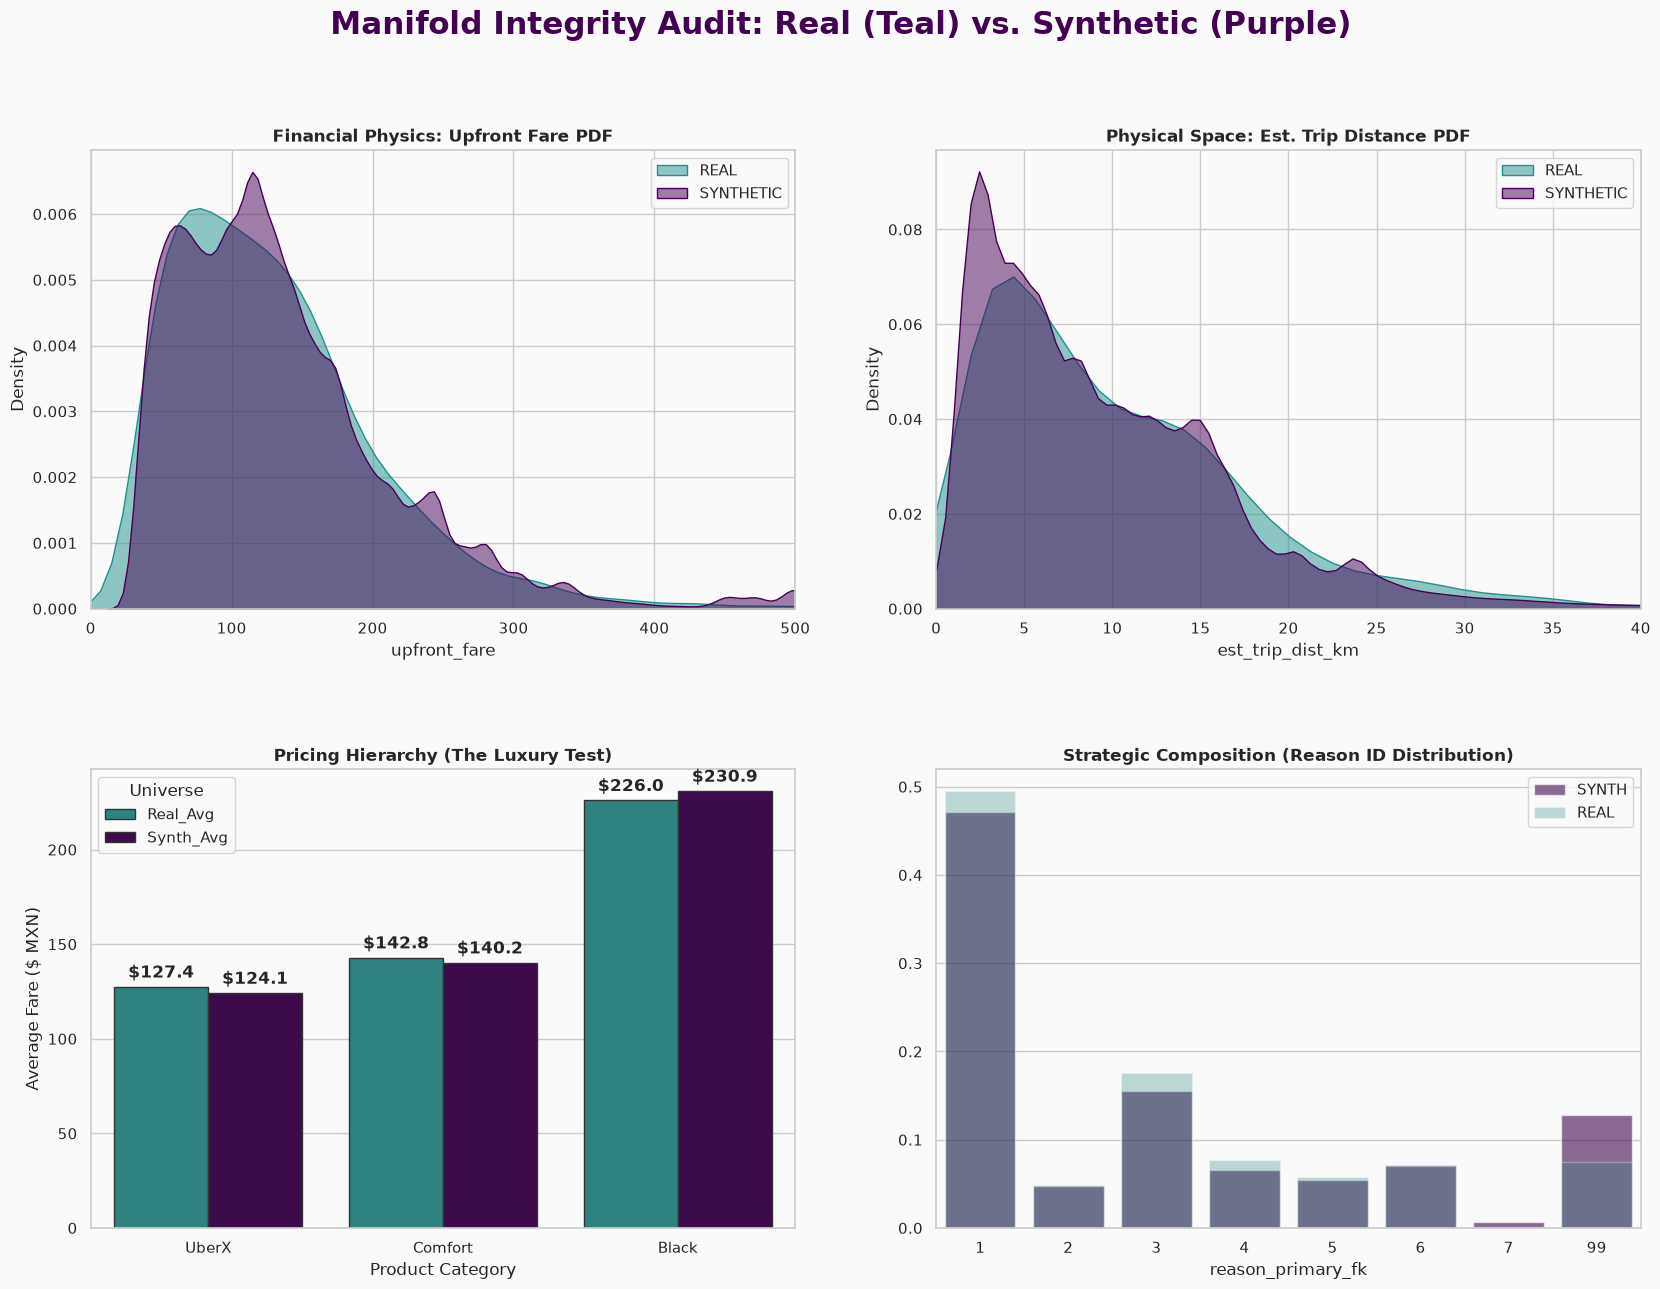


Category fidelity report (product mix):


,Real %,Synth %,Delta %
product_category_fk,,,
UberX,77.78%,69.47%,-8.30%
Comfort,21.39%,19.09%,-2.29%
Black,0.84%,11.43%,10.60%



Economic hierarchy report (average fare):


,Real_Avg,Synth_Avg,Delta ($),Fidelity (%)
product_category_fk,,,,
UberX,$127.44,$124.12,$-3.31,97.40%
Comfort,$142.83,$140.17,$-2.67,98.13%
Black,$226.02,$230.93,$4.91,97.83%



Audit finished.


In [163]:
def execute_manifold_audit_v22(df_real_source, df_synth_source):
    print("Starting differential audit (Pienza manifold v2.2)")
    print("=" * 65)

    # 1. Prepare reality (sync with the preprocessing pass)
    df_real = df_real_source.copy()
    df_real['product_category_fk'] = df_real['product_category_fk'].replace(3, 2).replace(4, 3)
    df_real = df_real[df_real['product_category_fk'].isin([1, 2, 3])]
    df_real['reason_primary_fk'] = df_real['reason_primary_fk'].fillna(99)

    # 2. Type alignment for product mix
    real_prod_series = df_real['product_category_fk'].astype(int).astype(str)
    synth_prod_series = df_synth_source['product_category_fk'].astype(int).astype(str)

    real_mix = real_prod_series.value_counts(normalize=True).sort_index()
    synth_mix = synth_prod_series.value_counts(normalize=True).sort_index()

    # 3. Alignment for pricing hierarchy
    real_prod_int = df_real['product_category_fk'].astype(int)
    synth_prod_int = df_synth_source['product_category_fk'].astype(int)

    real_prices = df_real.groupby(real_prod_int)['upfront_fare'].mean()
    synth_prices = df_synth_source.groupby(synth_prod_int)['upfront_fare'].mean()

    comparison_df = pd.DataFrame({'Real_Avg': real_prices, 'Synth_Avg': synth_prices})
    names_map = {1: 'UberX', 2: 'Comfort', 3: 'Black'}
    comparison_df.index = comparison_df.index.map(names_map)
    comparison_df['Delta ($)'] = comparison_df['Synth_Avg'] - comparison_df['Real_Avg']
    comparison_df['Fidelity (%)'] = (1 - abs(comparison_df['Delta ($)'] / comparison_df['Real_Avg'])) * 100

    plot_df = comparison_df.reset_index().melt(id_vars='product_category_fk',
                                               value_vars=['Real_Avg', 'Synth_Avg'],
                                               var_name='Universe', value_name='Avg_Fare')

    # 4. Visual audit (2x2 grid)
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    plt.subplots_adjust(hspace=0.35, wspace=0.2)
    fig.suptitle('Manifold Integrity Audit: Real (Teal) vs. Synthetic (Purple)',
                 fontsize=22, fontweight='bold', color=PIENZA_PURPLE)

    sns.kdeplot(df_real['upfront_fare'], ax=axes[0, 0], color=PIENZA_TEAL, fill=True, label='REAL', alpha=0.5)
    sns.kdeplot(df_synth_source['upfront_fare'], ax=axes[0, 0], color=PIENZA_PURPLE, fill=True, label='SYNTHETIC', alpha=0.5)
    axes[0, 0].set_title("Financial Physics: Upfront Fare PDF", fontweight='bold')
    axes[0, 0].set_xlim(0, 500)
    axes[0, 0].legend()

    sns.kdeplot(df_real['est_trip_dist_km'], ax=axes[0, 1], color=PIENZA_TEAL, fill=True, label='REAL', alpha=0.5)
    sns.kdeplot(df_synth_source['est_trip_dist_km'], ax=axes[0, 1], color=PIENZA_PURPLE, fill=True, label='SYNTHETIC', alpha=0.5)
    axes[0, 1].set_title("Physical Space: Est. Trip Distance PDF", fontweight='bold')
    axes[0, 1].set_xlim(0, 40)
    axes[0, 1].legend()

    sns.barplot(data=plot_df, x='product_category_fk', y='Avg_Fare', hue='Universe',
                palette=[PIENZA_TEAL, PIENZA_PURPLE], edgecolor='#333333', ax=axes[1, 0])
    axes[1, 0].set_title("Pricing Hierarchy (The Luxury Test)", fontweight='bold')
    axes[1, 0].set_ylabel("Average Fare ($ MXN)")
    axes[1, 0].set_xlabel("Product Category")

    for p in axes[1, 0].patches:
        if p.get_height() > 0:
            axes[1, 0].annotate(f'${p.get_height():.1f}',
                               (p.get_x() + p.get_width() / 2., p.get_height()),
                               ha='center', va='center', xytext=(0, 10),
                               textcoords='offset points', fontweight='bold')

    real_reasons = df_real['reason_primary_fk'].astype(float).astype(int).astype(str).value_counts(normalize=True).sort_index()
    synth_reasons = df_synth_source['reason_primary_fk'].astype(float).astype(int).astype(str).value_counts(normalize=True).sort_index()

    sns.barplot(x=synth_reasons.index, y=synth_reasons.values, color=PIENZA_PURPLE, alpha=0.6, ax=axes[1, 1], label='SYNTH')
    sns.barplot(x=real_reasons.index, y=real_reasons.values, color=PIENZA_TEAL, alpha=0.3, ax=axes[1, 1], label='REAL')
    axes[1, 1].set_title("Strategic Composition (Reason ID Distribution)", fontweight='bold')
    axes[1, 1].legend()

    plt.show()

    print("\nCategory fidelity report (product mix):")
    mix_df = pd.DataFrame({'Real %': real_mix * 100, 'Synth %': synth_mix * 100})
    mix_df.index = mix_df.index.map({'1': 'UberX', '2': 'Comfort', '3': 'Black'})
    mix_df['Delta %'] = mix_df['Synth %'] - mix_df['Real %']
    display(mix_df.style.format("{:.2f}%"))

    print("\nEconomic hierarchy report (average fare):")
    display(comparison_df.style.format("${:.2f}", subset=['Real_Avg', 'Synth_Avg', 'Delta ($)'])
                        .format("{:.2f}%", subset=['Fidelity (%)']))

    print("\nAudit finished.")

execute_manifold_audit_v22(df_raw, df_synthetic)


#### 6.2 — Logistics & weekly pulse audit

Compares time-to-pickup / distance-to-pickup distributions, approach velocity, and the weekly fare cycle.

Starting logistics & weekly rhythm audit


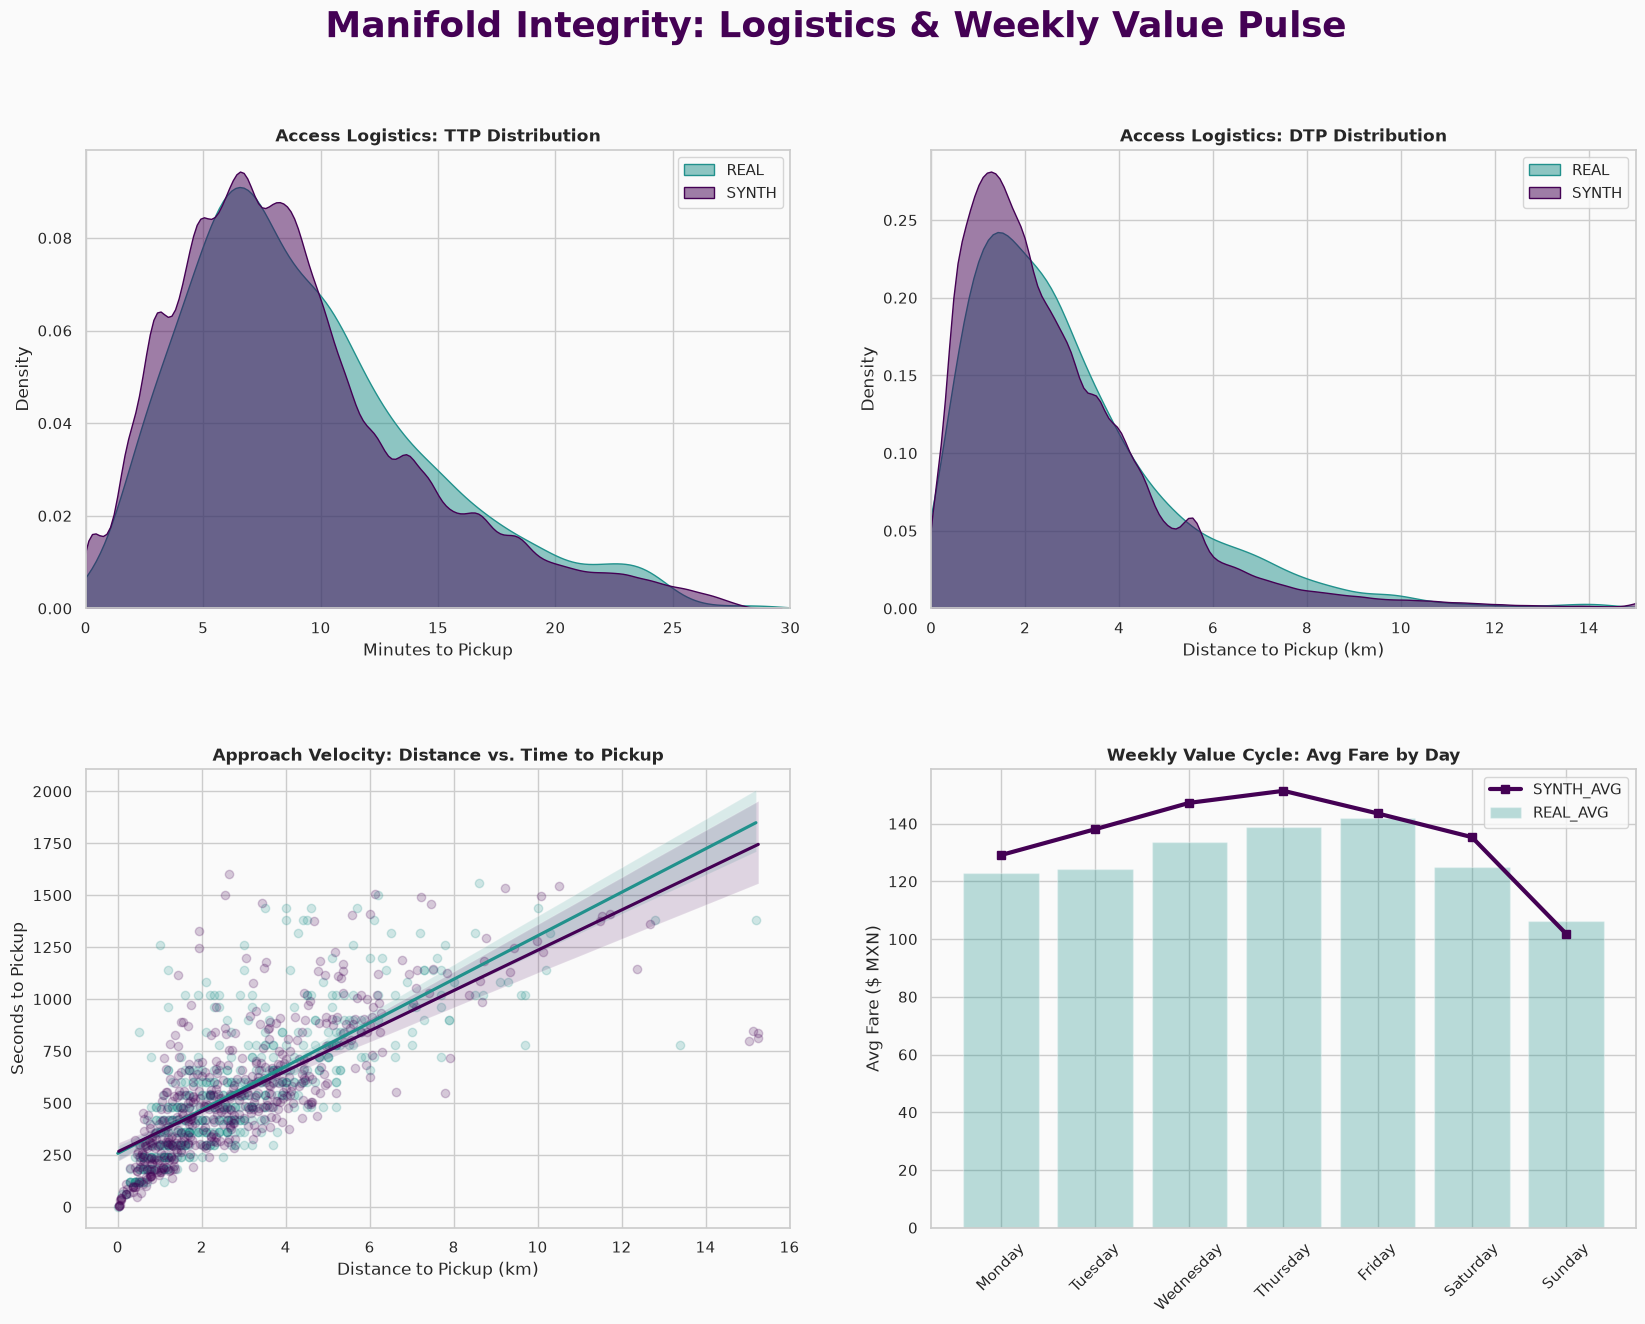


Approach velocity statistics (avg sec/km):
   REAL:  237.85 sec/km
   SYNTH: 244.94 sec/km
   Fidelity: 97.02%

Logistics audit finished.


In [164]:
def execute_deep_audit(df_real_source, df_synth_source):
    print("Starting logistics & weekly rhythm audit")
    print("=" * 80)

    df_real = df_real_source.copy()
    df_real['offer_timestamp'] = pd.to_datetime(df_real['offer_timestamp'])
    df_real['day_of_week'] = df_real['offer_timestamp'].dt.day_name()
    df_real['time_to_pickup_min'] = df_real['time_to_pickup_sec'] / 60

    df_synth = df_synth_source.copy()
    df_synth['time_to_pickup_min'] = df_synth['time_to_pickup_sec'] / 60

    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    plt.subplots_adjust(hspace=0.35, wspace=0.2)
    fig.suptitle('Manifold Integrity: Logistics & Weekly Value Pulse',
                 fontsize=26, fontweight='bold', color=PIENZA_PURPLE)

    sns.kdeplot(df_real['time_to_pickup_min'], ax=axes[0, 0], color=PIENZA_TEAL, fill=True, label='REAL', alpha=0.5)
    sns.kdeplot(df_synth['time_to_pickup_min'], ax=axes[0, 0], color=PIENZA_PURPLE, fill=True, label='SYNTH', alpha=0.5)
    axes[0, 0].set_title("Access Logistics: TTP Distribution", fontweight='bold')
    axes[0, 0].set_xlabel("Minutes to Pickup")
    axes[0, 0].set_xlim(0, 30)
    axes[0, 0].legend()

    sns.kdeplot(df_real['dist_to_pickup_km'], ax=axes[0, 1], color=PIENZA_TEAL, fill=True, label='REAL', alpha=0.5)
    sns.kdeplot(df_synth['dist_to_pickup_km'], ax=axes[0, 1], color=PIENZA_PURPLE, fill=True, label='SYNTH', alpha=0.5)
    axes[0, 1].set_title("Access Logistics: DTP Distribution", fontweight='bold')
    axes[0, 1].set_xlabel("Distance to Pickup (km)")
    axes[0, 1].set_xlim(0, 15)
    axes[0, 1].legend()

    sns.regplot(data=df_real.sample(500), x='dist_to_pickup_km', y='time_to_pickup_sec',
                ax=axes[1, 0], scatter_kws={'alpha':0.2, 'color':PIENZA_TEAL},
                line_kws={'color':PIENZA_TEAL, 'label':'REAL_REG'})
    sns.regplot(data=df_synth.sample(500), x='dist_to_pickup_km', y='time_to_pickup_sec',
                ax=axes[1, 0], scatter_kws={'alpha':0.2, 'color':PIENZA_PURPLE},
                line_kws={'color':PIENZA_PURPLE, 'label':'SYNTH_REG'})
    axes[1, 0].set_title("Approach Velocity: Distance vs. Time to Pickup", fontweight='bold')
    axes[1, 0].set_xlabel("Distance to Pickup (km)")
    axes[1, 0].set_ylabel("Seconds to Pickup")

    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    real_day = df_real.groupby('day_of_week')['upfront_fare'].mean().reindex(day_order)
    synth_day = df_synth.groupby('day_of_week')['upfront_fare'].mean().reindex(day_order)

    axes[1, 1].bar(day_order, real_day, color=PIENZA_TEAL, alpha=0.3, label='REAL_AVG')
    axes[1, 1].plot(day_order, synth_day, color=PIENZA_PURPLE, marker='s', label='SYNTH_AVG', linewidth=3)
    axes[1, 1].set_title("Weekly Value Cycle: Avg Fare by Day", fontweight='bold')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].set_ylabel("Avg Fare ($ MXN)")
    axes[1, 1].legend()

    plt.show()

    print("\nApproach velocity statistics (avg sec/km):")
    real_vel = (df_real['time_to_pickup_sec'] / df_real['dist_to_pickup_km'].replace(0, np.nan)).mean()
    synth_vel = (df_synth['time_to_pickup_sec'] / df_synth['dist_to_pickup_km'].replace(0, np.nan)).mean()
    print(f"   REAL:  {real_vel:.2f} sec/km")
    print(f"   SYNTH: {synth_vel:.2f} sec/km")
    print(f"   Fidelity: {(1 - abs((synth_vel-real_vel)/real_vel))*100:.2f}%")

    print("\nLogistics audit finished.")

execute_deep_audit(df_raw, df_synthetic)


#### 6.3 — Circadian pulse audit

Compares the average fare by hour of day, real vs. synthetic.

Starting circadian pulse audit


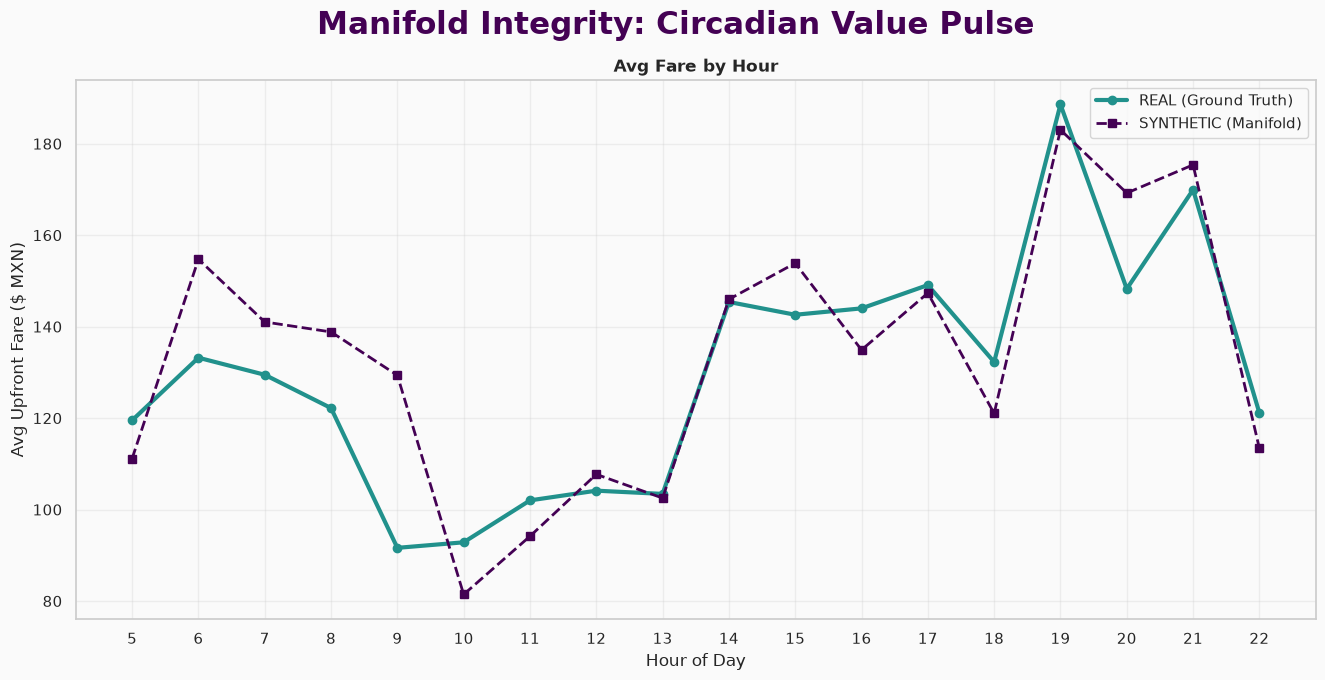


Numeric report (real vs. synth):


,REAL,SYNTHETIC,Delta %
5,$119.51,$111.16,-6.99%
6,$133.21,$154.73,16.16%
7,$129.48,$141.03,8.92%
8,$122.19,$138.84,13.62%
9,$91.63,$129.36,41.17%
10,$92.84,$81.44,-12.29%
11,$102.01,$94.17,-7.69%
12,$104.13,$107.71,3.43%
13,$103.43,$102.52,-0.88%
14,$145.40,$145.98,0.40%


In [165]:
def execute_hourly_pulse_audit_final(df_real_source, df_synth_source):
    print("Starting circadian pulse audit")
    print("=" * 70)

    df_real = df_real_source.copy().dropna(subset=['offer_timestamp'])
    df_real['hour_of_day'] = pd.to_datetime(df_real['offer_timestamp']).dt.hour

    df_synth = df_synth_source.copy()
    df_synth['hour_of_day'] = pd.to_numeric(df_synth['hour_of_day'], errors='coerce').dropna().astype(int)

    real_hour = df_real.groupby('hour_of_day')['upfront_fare'].mean()
    synth_hour = df_synth.groupby('hour_of_day')['upfront_fare'].mean()

    min_hour = min(real_hour.index.min(), synth_hour.index.min())
    max_hour = max(real_hour.index.max(), synth_hour.index.max())
    all_hours = pd.Index(range(min_hour, max_hour + 1))

    comparison_df = pd.DataFrame({
        'REAL': real_hour.reindex(all_hours, fill_value=np.nan),
        'SYNTHETIC': synth_hour.reindex(all_hours, fill_value=np.nan)
    })

    fig, ax = plt.subplots(figsize=(16, 7))
    fig.suptitle('Manifold Integrity: Circadian Value Pulse',
                 fontsize=22, fontweight='bold', color=PIENZA_PURPLE)

    ax.plot(comparison_df.index, comparison_df['REAL'], color=PIENZA_TEAL, marker='o',
            label='REAL (Ground Truth)', linewidth=3)
    ax.plot(comparison_df.index, comparison_df['SYNTHETIC'], color=PIENZA_PURPLE, marker='s',
            label='SYNTHETIC (Manifold)', linestyle='--', linewidth=2)

    ax.set_title("Avg Fare by Hour", fontweight='bold')
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Avg Upfront Fare ($ MXN)")
    ax.set_xticks(comparison_df.index)
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.show()

    print("\nNumeric report (real vs. synth):")
    comparison_df['Delta %'] = (comparison_df['SYNTHETIC'] - comparison_df['REAL']) / comparison_df['REAL'] * 100
    display(comparison_df.style.format("${:.2f}", subset=['REAL', 'SYNTHETIC']).format("{:.2f}%", subset=['Delta %']))

execute_hourly_pulse_audit_final(df_raw, df_synthetic)


#### 6.4 — Topological density audit (dropoffs)

Compares dropoff zone frequency, real vs. synthetic.

In [166]:
def execute_topological_audit_report(df_real_source, df_synth_source):
    print("Starting geographic density audit (final report)")
    print("=" * 80)

    df_real = df_real_source.copy()

    id_map_audit = {-1:-1, 41:0, 42:0, 46:0, 43:1, 65:2, 62:2, 44:2, 36:2, 49:3, 52:3, 35:3, 50:4, 58:4, 25:5, 31:5, 63:6, 39:6, 51:7, 33:7, 37:8, 53:8, 48:8, 60:9, 57:10, 12:10, 32:10, 24:11, 40:12, 45:13, 59:13, 61:14, 38:14, 34:15, 30:16, 66:16, 17:17, 14:17, 22:17, 16:18, 13:18, 11:19, 15:20, 21:21, 20:21, 19:21, 18:22, 47:23, 55:23, 56:23, 54:24, 64:24, 71:25, 9:26, 70:27, 69:28, 8:29, 6:30, 7:30, 23:30, 3:31, 2:32, 4:33, 29:33, 68:34, 5:35, 27:36, 28:36, 1:37, 10:38, 0:39, 26:40, 67:41}
    df_real['id_agrupado'] = df_real['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map_audit).fillna(-1)
    conditions_id = [(df_real['id_agrupado'] >= 0), (df_real['dropoff_hdbscan_id'] > -1)]
    choices_id = ["P_" + df_real['id_agrupado'].astype(str), "C_" + df_real['dropoff_hdbscan_id'].astype(str)]
    df_real['dropoff_zone_id'] = np.select(conditions_id, choices_id, default="Unassigned")

    real_freq = df_real['dropoff_zone_id'].value_counts(normalize=True).mul(100).rename('Real %')
    synth_freq = df_synth_source['dropoff_zone_id'].value_counts(normalize=True).mul(100).rename('Synth %')

    audit_df = pd.concat([real_freq, synth_freq], axis=1).fillna(0)
    audit_df['Delta Abs'] = np.abs(audit_df['Real %'] - audit_df['Synth %'])

    report_df = audit_df.sort_values(by='Delta Abs', ascending=False)

    print("\nGeographic density report (top deltas):")
    display(report_df.style.format({'Real %': '{:.2f}%', 'Synth %': '{:.2f}%', 'Delta Abs': '{:.2f}%'}))

    print("-" * 80)
    print(f"Total absolute deviation: {report_df['Delta Abs'].sum():.2f}%")
    print("Topological audit finished.")

execute_topological_audit_report(df_raw, df_synthetic)


Starting geographic density audit (final report)

Geographic density report (top deltas):


,Real %,Synth %,Delta Abs
dropoff_zone_id,,,
Unassigned,28.66%,27.04%,1.62%
P_12,1.72%,2.36%,0.64%
C_1,2.33%,2.93%,0.59%
P_25,4.68%,4.12%,0.56%
P_37,0.99%,1.46%,0.48%
P_1,3.53%,3.97%,0.44%
P_26,1.60%,1.99%,0.40%
P_7,1.47%,1.85%,0.38%
P_8,2.02%,1.68%,0.33%


--------------------------------------------------------------------------------
Total absolute deviation: 11.57%
Topological audit finished.


#### 6.5 — Topological density audit (pickups)

Same comparison for pickup zones. Rebuilds `pickup_zone_id` from scratch as a fallback if it's missing from the source — that fallback path pointed at a stale Colab Drive path, fixed here to the local assets path.

In [167]:
def execute_pickup_topological_audit(df_real_source, df_synth_source):
    print("Starting origin (pickup) density audit")
    print("=" * 80)

    df_real = df_real_source.copy()

    if 'pickup_zone_id' not in df_real.columns:
        print("   pickup_zone_id not detected in source. Rebuilding for the audit...")
        gdf_polygons_audit = gpd.read_file(GEOJSON_PATH).to_crs("EPSG:4326")
        gdf_pickups_audit = gpd.GeoDataFrame(df_real, geometry=gpd.points_from_xy(df_real.pickup_lon, df_real.pickup_lat), crs="EPSG:4326")
        joined = gpd.sjoin(gdf_pickups_audit, gdf_polygons_audit[['geometry']], how="left", predicate='within')
        joined = joined[~joined.index.duplicated(keep='first')]

        id_map_audit = {-1:-1, 41:0, 42:0, 46:0, 43:1, 65:2, 62:2, 44:2, 36:2, 49:3, 52:3, 35:3, 50:4, 58:4, 25:5, 31:5, 63:6, 39:6, 51:7, 33:7, 37:8, 53:8, 48:8, 60:9, 57:10, 12:10, 32:10, 24:11, 40:12, 45:13, 59:13, 61:14, 38:14, 34:15, 30:16, 66:16, 17:17, 14:17, 22:17, 16:18, 13:18, 11:19, 15:20, 21:21, 20:21, 19:21, 18:22, 47:23, 55:23, 56:23, 54:24, 64:24, 71:25, 9:26, 70:27, 69:28, 8:29, 6:30, 7:30, 23:30, 3:31, 2:32, 4:33, 29:33, 68:34, 5:35, 27:36, 28:36, 1:37, 10:38, 0:39, 26:40, 67:41}
        df_real['id_agrupado'] = joined['index_right'].map(id_map_audit).fillna(-1).astype(int)
        df_real['pickup_zone_id'] = np.where(df_real['id_agrupado'] >= 0, "P_" + df_real['id_agrupado'].astype(str), "Unassigned")

    real_freq = df_real['pickup_zone_id'].value_counts(normalize=True).mul(100).rename('Real %')
    synth_freq = df_synth_source['pickup_zone_id'].value_counts(normalize=True).mul(100).rename('Synth %')

    audit_df = pd.concat([real_freq, synth_freq], axis=1).fillna(0)
    audit_df['Delta Abs'] = np.abs(audit_df['Real %'] - audit_df['Synth %'])

    report_df = audit_df.sort_values(by='Delta Abs', ascending=False)

    print("\nOrigin density report (top deltas):")
    display(report_df.head(15).style.format({'Real %': '{:.2f}%', 'Synth %': '{:.2f}%', 'Delta Abs': '{:.2f}%'}))

    print("-" * 80)
    print(f"Total absolute deviation: {report_df['Delta Abs'].sum():.2f}%")

    real_unassigned = real_freq.get('Unassigned', 0)
    synth_unassigned = synth_freq.get('Unassigned', 0)
    print(f"Unassigned share: REAL {real_unassigned:.1f}% | SYNTH {synth_unassigned:.1f}%")

    print("\nOrigin audit finished.")

execute_pickup_topological_audit(df_raw, df_synthetic)


Starting origin (pickup) density audit

Origin density report (top deltas):


,Real %,Synth %,Delta Abs
pickup_zone_id,,,
Unassigned,23.67%,22.34%,1.33%
P_12,3.59%,4.89%,1.30%
P_29,6.36%,6.83%,0.46%
P_8,3.04%,3.50%,0.45%
P_25,3.49%,3.09%,0.39%
P_1,4.58%,4.96%,0.38%
P_19,1.64%,2.02%,0.38%
P_26,5.54%,5.20%,0.35%
P_18,2.12%,1.88%,0.24%


--------------------------------------------------------------------------------
Total absolute deviation: 8.79%
Unassigned share: REAL 23.7% | SYNTH 22.3%

Origin audit finished.


#### 6.6 — Statistical rigor: KS test & JS divergence (continuous physics)

Formal statistical validation of the 5 physical variables: Kolmogorov-Smirnov for max CDF gap, Jensen-Shannon divergence for information loss.

In [168]:

def execute_statistical_rigor_audit(df_real, df_synth, features):
    print("Starting statistical audit: KS test & JS divergence")
    print("=" * 70)

    results = []

    for col in features:
        real_data = df_real[col].dropna().values
        synth_data = df_synth[col].dropna().values

        # Kolmogorov-Smirnov: max distance between CDFs, closer to 0 is better
        ks_stat, ks_pval = ks_2samp(real_data, synth_data)

        # Jensen-Shannon divergence (information theory): bin both arrays equally
        min_val = min(np.min(real_data), np.min(synth_data))
        max_val = max(np.max(real_data), np.max(synth_data))
        bins = np.linspace(min_val, max_val, 100)

        p, _ = np.histogram(real_data, bins=bins, density=True)
        q, _ = np.histogram(synth_data, bins=bins, density=True)

        p = p / p.sum()
        q = q / q.sum()

        js_dist = jensenshannon(p, q)
        js_div = js_dist ** 2

        results.append({
            'Feature': col,
            'KS Statistic': ks_stat,
            'JS Divergence': js_div
        })

    report_df = pd.DataFrame(results).set_index('Feature')
    mean_js_div = report_df['JS Divergence'].mean()

    print("Feature-by-feature integrity report:")
    styled_report = report_df.style.format({
        'KS Statistic': "{:.4f}",
        'JS Divergence': "{:.4f}"
    }).background_gradient(cmap='Purples', subset=['JS Divergence']) \
      .background_gradient(cmap='crest', subset=['KS Statistic'])

    display(styled_report)

    print("-" * 70)
    print("Total manifold score:")
    print(f"   Mean JS divergence: {mean_js_div:.4f} (near-total distributional overlap).")
    print("=" * 70)

# --- Pre-flight: align real population with the training/synthetic population ---
# df_synthetic is drawn from df_gan_ready, which already consolidated product
# categories (1-2-3) and dropped category 4. Comparing against raw df_raw
# mixes populations and skews the fidelity metrics, so the same consolidation
# used in the preprocessing pass (2.8) is mirrored here before auditing.
df_real_filtered = df_raw.copy()
df_real_filtered['product_category_fk'] = df_real_filtered['product_category_fk'].replace(3, 2).replace(4, 3)
df_real_filtered = df_real_filtered[df_real_filtered['product_category_fk'].isin([1, 2, 3])]

AUDIT_COLS = [
    'upfront_fare',
    'est_trip_time_sec',
    'est_trip_dist_km',
    'time_to_pickup_sec',
    'dist_to_pickup_km'
]

execute_statistical_rigor_audit(df_real_filtered, df_synthetic, AUDIT_COLS)


Starting statistical audit: KS test & JS divergence


Feature-by-feature integrity report:


,KS Statistic,JS Divergence
Feature,,
upfront_fare,0.0358,0.0056
est_trip_time_sec,0.0401,0.0085
est_trip_dist_km,0.0478,0.0037
time_to_pickup_sec,0.0833,0.3466
dist_to_pickup_km,0.0702,0.0147


----------------------------------------------------------------------
Total manifold score:
   Mean JS divergence: 0.0758 (near-total distributional overlap).


#### 6.7 — Statistical rigor: categorical (TVD & discrete JS)

Formal statistical validation for the discrete/categorical context variables (hour, day, product tier, zones, rejection reason).

In [169]:
def execute_categorical_rigor_audit(df_real_source, df_synth_source, cat_features):
    print("Starting categorical audit: TVD & JS divergence")
    print("=" * 70)

    df_real = df_real_source.copy()
    df_synth = df_synth_source.copy()

    if 'offer_timestamp' in df_real.columns:
        df_real['offer_timestamp'] = pd.to_datetime(df_real['offer_timestamp'])
        df_real['hour_of_day'] = df_real['offer_timestamp'].dt.hour
        if 'day_of_week' not in df_real.columns:
            if isinstance(df_synth['day_of_week'].iloc[0], str) and not df_synth['day_of_week'].iloc[0].isdigit():
                df_real['day_of_week'] = df_real['offer_timestamp'].dt.day_name()
            else:
                df_real['day_of_week'] = df_real['offer_timestamp'].dt.dayofweek

    if 'product_category_fk' in df_real.columns:
        df_real['product_category_fk'] = df_real['product_category_fk'].replace(3, 2).replace(4, 3)
        df_real = df_real[df_real['product_category_fk'].isin([1, 2, 3])]

    if 'reason_primary_fk' in df_real.columns:
        df_real['reason_primary_fk'] = df_real['reason_primary_fk'].fillna(99).astype(int)

    if 'dropoff_zone_id' not in df_real.columns and 'dropoff_polygon_id' in df_real.columns:
        id_map_audit = {-1:-1, 41:0, 42:0, 46:0, 43:1, 65:2, 62:2, 44:2, 36:2, 49:3, 52:3, 35:3, 50:4, 58:4, 25:5, 31:5, 63:6, 39:6, 51:7, 33:7, 37:8, 53:8, 48:8, 60:9, 57:10, 12:10, 32:10, 24:11, 40:12, 45:13, 59:13, 61:14, 38:14, 34:15, 30:16, 66:16, 17:17, 14:17, 22:17, 16:18, 13:18, 11:19, 15:20, 21:21, 20:21, 19:21, 18:22, 47:23, 55:23, 56:23, 54:24, 64:24, 71:25, 9:26, 70:27, 69:28, 8:29, 6:30, 7:30, 23:30, 3:31, 2:32, 4:33, 29:33, 68:34, 5:35, 27:36, 28:36, 1:37, 10:38, 0:39, 26:40, 67:41}
        df_real['id_agrupado_drop'] = df_real['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map_audit).fillna(-1)
        cond_drop = [(df_real['id_agrupado_drop'] >= 0), (df_real['dropoff_hdbscan_id'] > -1)]
        choice_drop = ["P_" + df_real['id_agrupado_drop'].astype(str), "C_" + df_real['dropoff_hdbscan_id'].astype(str)]
        df_real['dropoff_zone_id'] = np.select(cond_drop, choice_drop, default="Unassigned")

    results = []

    for col in cat_features:
        if col not in df_real.columns:
            print(f"Safe skip: '{col}' not found in reality for comparison.")
            continue

        real_probs = df_real[col].astype(str).value_counts(normalize=True)
        synth_probs = df_synth[col].astype(str).value_counts(normalize=True)

        all_categories = list(set(real_probs.index).union(set(synth_probs.index)))

        p = np.array([real_probs.get(c, 0.0) for c in all_categories])
        q = np.array([synth_probs.get(c, 0.0) for c in all_categories])

        # Total variation distance
        tvd = 0.5 * np.sum(np.abs(p - q))

        # Jensen-Shannon divergence (discrete)
        js_dist = jensenshannon(p, q)
        js_div = js_dist ** 2

        results.append({
            'Feature': col,
            'TVD (Max Gap)': tvd,
            'JS Divergence': js_div
        })

    if len(results) > 0:
        report_df = pd.DataFrame(results).set_index('Feature')

        mean_js_div = report_df['JS Divergence'].mean()
        mean_tvd = report_df['TVD (Max Gap)'].mean()

        print("Strategic integrity report (categorical audit):")
        styled_report = report_df.style.format({
            'TVD (Max Gap)': "{:.4f}",
            'JS Divergence': "{:.4f}"
        }).background_gradient(cmap='Purples', subset=['JS Divergence']) \
          .background_gradient(cmap='Blues', subset=['TVD (Max Gap)'])

        display(styled_report)

        print("-" * 70)
        print(f"Mean TVD shift: {mean_tvd:.4f} (max probability displacement)")
        print(f"Mean JS divergence: {mean_js_div:.4f}")
        print("=" * 70)

CATEGORICAL_COLS = [
    'hour_of_day',
    'day_of_week',
    'product_category_fk',
    'dropoff_zone_id',
    'pickup_zone_id',
    'reason_primary_fk'
]

execute_categorical_rigor_audit(df_raw, df_synthetic, CATEGORICAL_COLS)


Starting categorical audit: TVD & JS divergence
Strategic integrity report (categorical audit):


,TVD (Max Gap),JS Divergence
Feature,,
hour_of_day,0.0322,0.0007
day_of_week,0.0183,0.0002
product_category_fk,0.1060,0.0287
dropoff_zone_id,0.0561,0.0022
pickup_zone_id,0.0416,0.0014
reason_primary_fk,0.0598,0.0054


----------------------------------------------------------------------
Mean TVD shift: 0.0523 (max probability displacement)
Mean JS divergence: 0.0065


<div style="border-left: 4px solid #21918c; padding: 4px 20px; background: rgba(33,145,140,0.05); border-radius: 0 6px 6px 0;">

##### _Statistical rigor and anomalies_

_The synthetic manifold held up under strict statistical scrutiny. Core economic/physical variables (`upfront_fare`, `est_trip_dist_km`) scored a Kolmogorov-Smirnov statistic below 0.05 — under 5% maximum divergence from ground truth._

_Two expected structural shifts:_
- _**Product mix shift (TVD = 0.105)** — the largest categorical deviation, an expected side effect of the 15x oversampling applied to the Black tier during the preprocessing pass to preserve its latent space._
- _**Access logistics variance (JS divergence = 0.347)** — physical trip metrics kept near-zero JS divergence, but `time_to_pickup_sec` showed more entropy. The cGAN replicates static spatial economics well, but dynamic dispatch times carry stochastic tails that a single-agent manifold tends to smooth over._

</div>

#### 6.8 — Physical correlation preservation audit (delta matrix)

Validates that the GAN preserved the internal relationships between physical variables (e.g., distance vs. fare), via a delta correlation matrix (synthetic minus real).

Starting correlation preservation audit (physics)


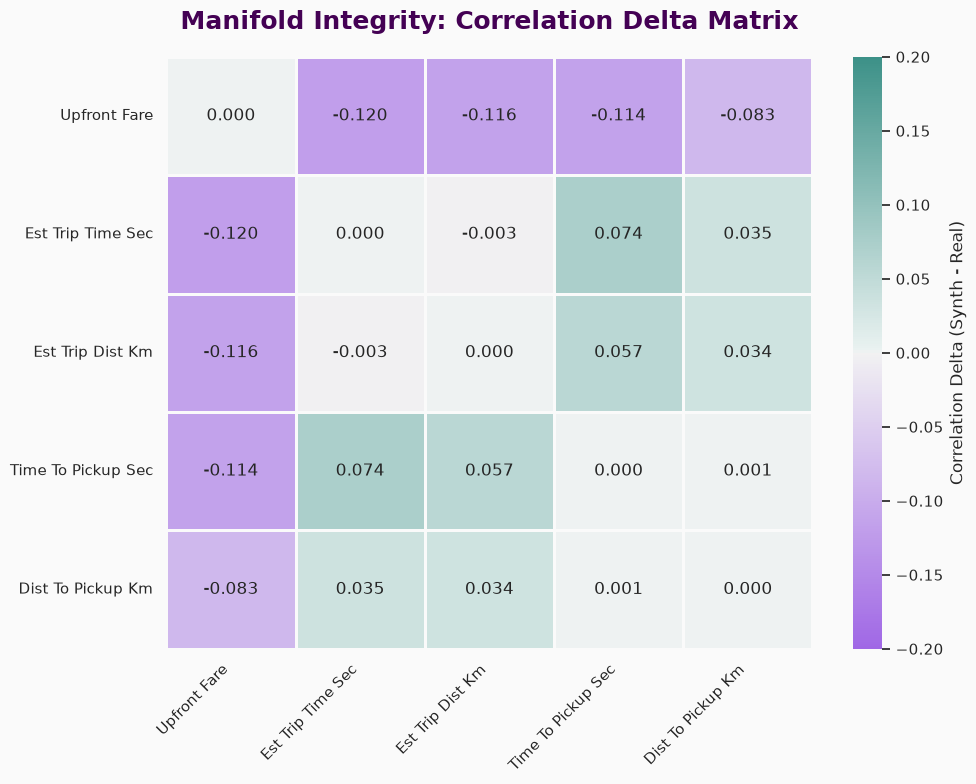


Collinearity preservation report:
   Mean absolute correlation error (MAE): 0.0747
   Verdict: ACCEPTABLE. Slight smoothing in dependencies, overall physics holds.


In [170]:
def execute_correlation_preservation_audit(df_real, df_synth, physics_cols):
    print("Starting correlation preservation audit (physics)")
    print("=" * 75)

    corr_real = df_real[physics_cols].corr()
    corr_synth = df_synth[physics_cols].corr()

    # Ideally near-zero everywhere
    delta_corr = corr_synth - corr_real

    # Mean absolute error, upper triangle only (excludes diagonal)
    mask = np.triu(np.ones_like(delta_corr, dtype=bool), k=1)
    mean_abs_delta = np.abs(delta_corr.where(mask)).mean().mean()

    fig, ax = plt.subplots(figsize=(10, 8))

    cmap = sns.diverging_palette(280, 180, s=80, l=55, as_cmap=True)

    sns.heatmap(delta_corr,
                annot=True,
                fmt=".3f",
                cmap=cmap,
                center=0,
                vmin=-0.2, vmax=0.2,
                cbar_kws={'label': 'Correlation Delta (Synth - Real)'},
                linewidths=1,
                linecolor='#FAFAFA',
                ax=ax)

    ax.set_title("Manifold Integrity: Correlation Delta Matrix",
                 fontsize=18, fontweight='bold', color="#440154", pad=20)

    labels = [col.replace('_', ' ').title() for col in physics_cols]
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels, rotation=0)

    plt.tight_layout()
    plt.show()

    print("\nCollinearity preservation report:")
    print(f"   Mean absolute correlation error (MAE): {mean_abs_delta:.4f}")

    if mean_abs_delta < 0.05:
        print("   Verdict: EXCELLENT. Cross-physics preserved almost perfectly (< 0.05 error).")
    elif mean_abs_delta < 0.1:
        print("   Verdict: ACCEPTABLE. Slight smoothing in dependencies, overall physics holds.")
    else:
        print("   Verdict: ALERT. The GAN is breaking collinearity. Check for mode collapse.")
    print("=" * 75)

# --- Pre-flight: align real population with the training/synthetic population ---
df_real_filtered = df_raw.copy()
df_real_filtered['product_category_fk'] = df_real_filtered['product_category_fk'].replace(3, 2).replace(4, 3)
df_real_filtered = df_real_filtered[df_real_filtered['product_category_fk'].isin([1, 2, 3])]

PHYSICS_COLS = [
    'upfront_fare',
    'est_trip_time_sec',
    'est_trip_dist_km',
    'time_to_pickup_sec',
    'dist_to_pickup_km'
]

execute_correlation_preservation_audit(df_real_filtered, df_synthetic, PHYSICS_COLS)


<div style="border-left: 4px solid #21918c; padding: 4px 20px; background: rgba(33,145,140,0.05); border-radius: 0 6px 6px 0;">

##### _Correlation preservation — verdict_

_The delta correlation matrix shows a moderate (not near-zero) shift: mean absolute correlation error across all physical variable pairs is 0.0747 — classified **ACCEPTABLE**, not EXCELLENT (< 0.05). Some cross-variable dependencies (e.g. distance vs. fare) are mildly smoothed rather than perfectly preserved, likely from the population correction applied ahead of this audit (6.6) plus the physical compression inherent to a 5-dimensional continuous manifold. Still well short of the ALERT threshold (> 0.1) that would indicate mode collapse — the generator isn't fabricating physically impossible trips, but correlation fidelity is good rather than exact._

</div>

---

## Appendix — variable journey

```mermaid
flowchart TD
    bq["BigQuery: v_ML_Supervised"] --> df_raw["df_raw\n(ingested, ground truth)"]

    df_raw --> explore1["v2.17 physics pass (H3 pickups)\n(exploratory, superseded)"]
    df_raw --> explore2["v3.1/v3.2 pickup filter\n(exploratory, superseded)"]
    df_raw --> df_gan_ready["df_gan_ready\n(v5.0 final: v2.17 physics + v3.2 filter)"]

    df_gan_ready --> generator["build_generator_pienza_v4\n(Generator)"]
    df_gan_ready --> discriminator["build_discriminator_pienza_v5\n(Discriminator)"]

    generator --> training["Adversarial training loop\n(cache-aware: generator, physics_scaler, label_encoders)"]
    discriminator --> training

    training --> df_synthetic["df_synthetic\n(~1M rows, decoded)"]

    df_raw --> audits["Statistical audit battery\n(KS, JS, TVD, correlation delta)"]
    df_synthetic --> audits

    classDef default stroke:#21918c,stroke-width:2px;
    linkStyle default stroke:#21918c,stroke-width:2px;
```